In [1]:
# import os
# from google.colab import userdata

# # Retrieve credentials
# token = userdata.get('GITHUB_TOKEN')
# username = "l3anxna" # YOUR GITHUB NAME
# repo_name = "what-you-eat-decides-your-grade"

# # Configure git URL
# repo_url = f"https://{token}@github.com/{username}/{repo_name}.git"

# # Clone if it doesn't exist, otherwise pull latest
# if not os.path.exists(repo_name):
#     !git clone {repo_url}
#     %cd {repo_name}
# else:
#     %cd {repo_name}
#     !git pull


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

plt.style.use("ggplot")

In [3]:
# ! git checkout develop
# ! git checkout -b taco-eda

In [4]:
! ls

data  notebook.ipynb


## 1. Load Dataset

In [5]:
df = pd.read_csv("data/food_coded.csv")

print("=" * 50)
print("Dataset Shape:", df.shape)
print("=" * 50)

df.head()

Dataset Shape: (125, 61)


,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.
3,3.2,1,1,430,3.0,420.0,2,"Pizza, Mac and cheese, ice cream",Boredom,2.0,...,1.0,2.0,5,725.0,690,NaN,3,1,1315,"Not sure, 240"
4,3.5,1,1,720,2.0,420.0,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,...,1.0,1.0,4,940.0,500,Softball,4,2,760,190


## 2. Dataset Information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    str    
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    str    
 8   comfort_food_reasons          123 non-null    str    
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-null    float64
 13  diet_current    

In [7]:
df.describe(include="all")

,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
count,123,125.000000,125.000000,125.000000,106.000000,124.000000,125.00000,124,123,106.000000,...,124.000000,123.000000,125.000000,124.000000,125.000000,99,125.000000,125.000000,125.000000,123
unique,38,NaN,NaN,NaN,NaN,NaN,NaN,124,106,NaN,...,NaN,NaN,NaN,NaN,NaN,66,NaN,NaN,NaN,47
top,3.5,NaN,NaN,NaN,NaN,NaN,NaN,none,boredom,NaN,...,NaN,NaN,NaN,NaN,NaN,none,NaN,NaN,NaN,135
freq,13,NaN,NaN,NaN,NaN,NaN,NaN,1,7,NaN,...,NaN,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,8
mean,NaN,1.392000,1.112000,577.320000,3.028302,505.241935,1.75200,NaN,NaN,2.698113,...,1.217742,1.390244,3.336000,947.580645,555.040000,NaN,4.008000,1.512000,1073.400000,NaN
std,NaN,0.490161,0.316636,131.214156,0.639308,230.840506,0.43359,NaN,NaN,1.972042,...,0.414385,0.489800,1.436528,202.090179,152.370379,NaN,1.081337,0.501867,248.667092,NaN
min,NaN,1.000000,1.000000,265.000000,2.000000,315.000000,1.00000,NaN,NaN,1.000000,...,1.000000,1.000000,1.000000,580.000000,345.000000,NaN,1.000000,1.000000,575.000000,NaN
25%,NaN,1.000000,1.000000,430.000000,3.000000,420.000000,2.00000,NaN,NaN,2.000000,...,1.000000,1.000000,2.000000,725.000000,500.000000,NaN,3.000000,1.000000,900.000000,NaN
50%,NaN,1.000000,1.000000,610.000000,3.000000,420.000000,2.00000,NaN,NaN,2.000000,...,1.000000,1.000000,3.000000,940.000000,500.000000,NaN,4.000000,2.000000,900.000000,NaN
75%,NaN,2.000000,1.000000,720.000000,3.000000,420.000000,2.00000,NaN,NaN,3.000000,...,1.000000,2.000000,5.000000,1165.000000,690.000000,NaN,5.000000,2.000000,1315.000000,NaN


## 3. Missing Value Analysis

In [8]:
missing_find = df.isnull().sum().sort_values(ascending=False)
missing = missing_find[missing_find > 0]

missing

type_sports                   26
comfort_food_reasons_coded    19
calories_day                  19
cuisine                       17
exercise                      13
employment                     9
eating_changes                 3
cook                           3
father_profession              3
meals_dinner_friend            3
mother_education               3
comfort_food_reasons           2
fav_cuisine                    2
mother_profession              2
drink                          2
weight                         2
sports                         2
fav_food                       2
GPA                            2
food_childhood                 1
father_education               1
ideal_diet                     1
income                         1
calories_scone                 1
diet_current                   1
comfort_food                   1
tortilla_calories              1
persian_food                   1
self_perception_weight         1
on_off_campus                  1
healthy_me

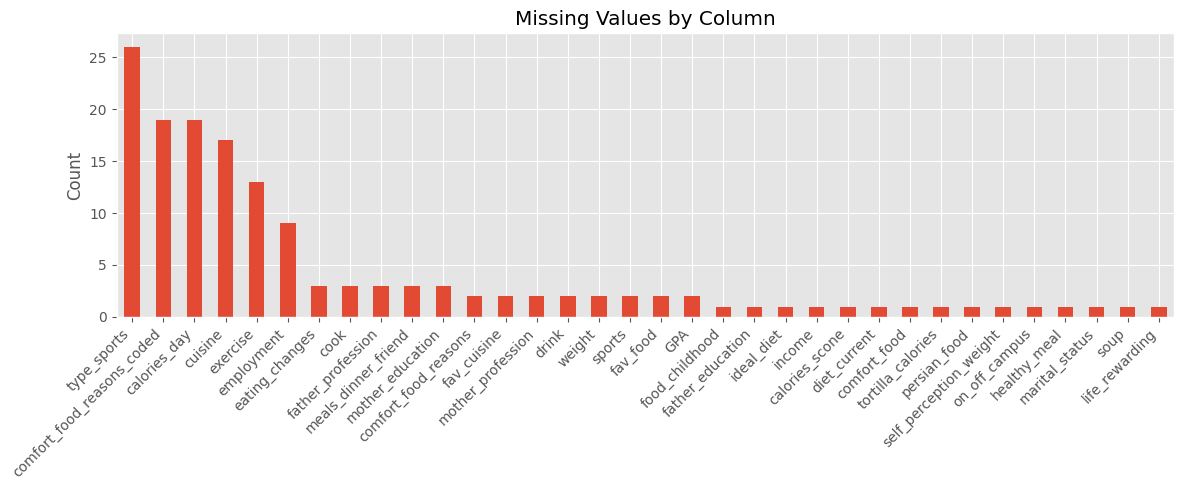

In [9]:
plt.figure(figsize=(12, 5))

missing.plot(kind="bar")

plt.title("Missing Values by Column")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 4. Duplicate Rows

In [10]:
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


## 5. Data Cleaning

In [11]:
df["GPA"] = pd.to_numeric(df["GPA"], errors="coerce")
df["weight"] = pd.to_numeric(df["weight"], errors="coerce")

## 6. Numerical Features

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns

print(numeric_cols)

df[numeric_cols].describe().T

Index(['GPA', 'Gender', 'breakfast', 'calories_chicken', 'calories_day',
       'calories_scone', 'coffee', 'comfort_food_reasons_coded', 'cook',
       'comfort_food_reasons_coded.1', 'cuisine', 'diet_current_coded',
       'drink', 'eating_changes_coded', 'eating_changes_coded1', 'eating_out',
       'employment', 'ethnic_food', 'exercise', 'father_education',
       'fav_cuisine_coded', 'fav_food', 'fries', 'fruit_day', 'grade_level',
       'greek_food', 'healthy_feeling', 'ideal_diet_coded', 'income',
       'indian_food', 'italian_food', 'life_rewarding', 'marital_status',
       'mother_education', 'nutritional_check', 'on_off_campus',
       'parents_cook', 'pay_meal_out', 'persian_food',
       'self_perception_weight', 'soup', 'sports', 'thai_food',
       'tortilla_calories', 'turkey_calories', 'veggies_day', 'vitamins',
       'waffle_calories', 'weight'],
      dtype='str')


,count,mean,std,min,25%,50%,75%,max
GPA,120.0,3.415558,0.390139,2.2,3.2,3.5,3.7,4.0
Gender,125.0,1.392000,0.490161,1.0,1.0,1.0,2.0,2.0
breakfast,125.0,1.112000,0.316636,1.0,1.0,1.0,1.0,2.0
calories_chicken,125.0,577.320000,131.214156,265.0,430.0,610.0,720.0,720.0
calories_day,106.0,3.028302,0.639308,2.0,3.0,3.0,3.0,4.0
calories_scone,124.0,505.241935,230.840506,315.0,420.0,420.0,420.0,980.0
coffee,125.0,1.752000,0.433590,1.0,2.0,2.0,2.0,2.0
comfort_food_reasons_coded,106.0,2.698113,1.972042,1.0,2.0,2.0,3.0,9.0
cook,122.0,2.786885,1.038351,1.0,2.0,3.0,3.0,5.0
comfort_food_reasons_coded.1,125.0,2.688000,1.910987,1.0,2.0,2.0,3.0,9.0


## 7. Correlation Matrix

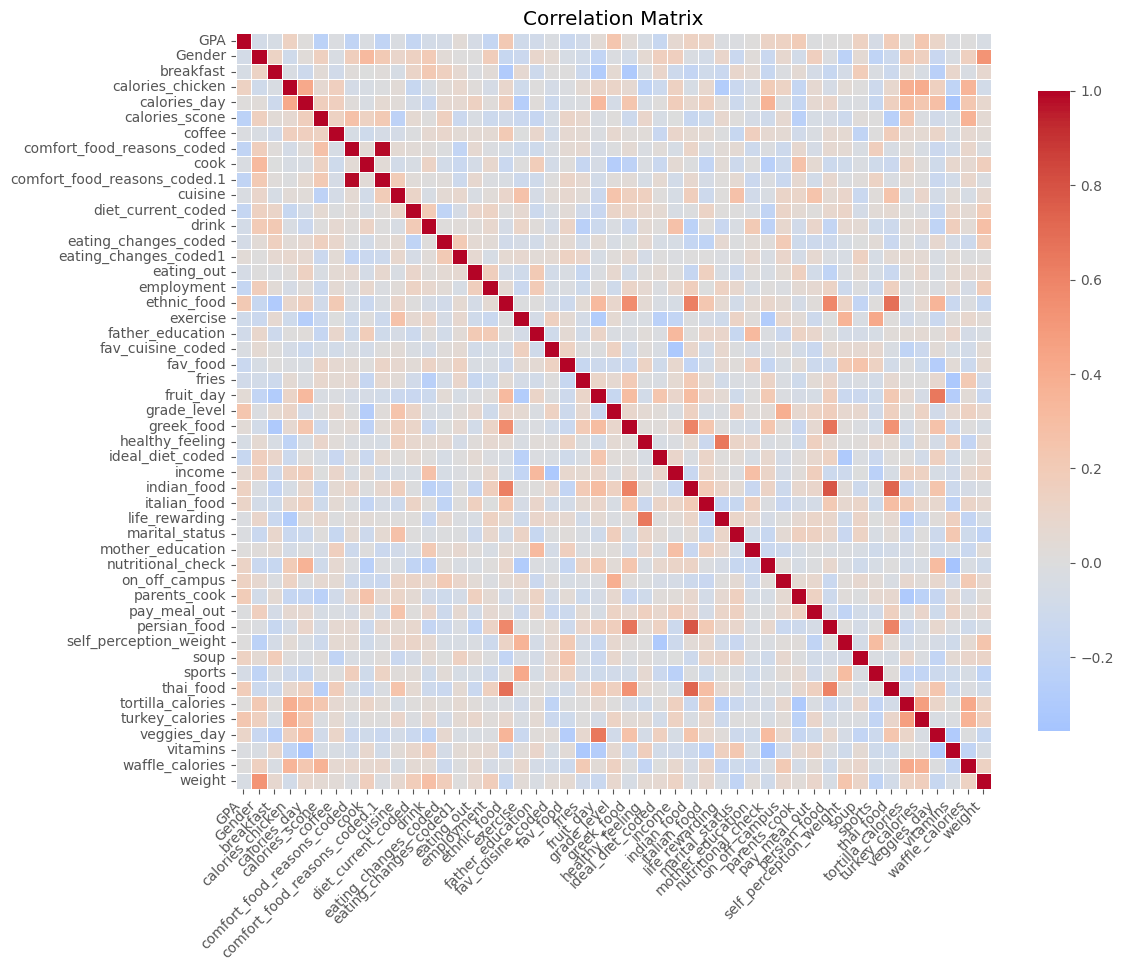

In [13]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Correlation Matrix")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## 8. Categorical Variables

In [14]:
cat_cols = df.select_dtypes(include="object").columns

cat_cols

/tmp/ipykernel_590/430473188.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


Index(['comfort_food', 'comfort_food_reasons', 'diet_current',
       'eating_changes', 'father_profession', 'fav_cuisine', 'food_childhood',
       'healthy_meal', 'ideal_diet', 'meals_dinner_friend',
       'mother_profession', 'type_sports'],
      dtype='str')

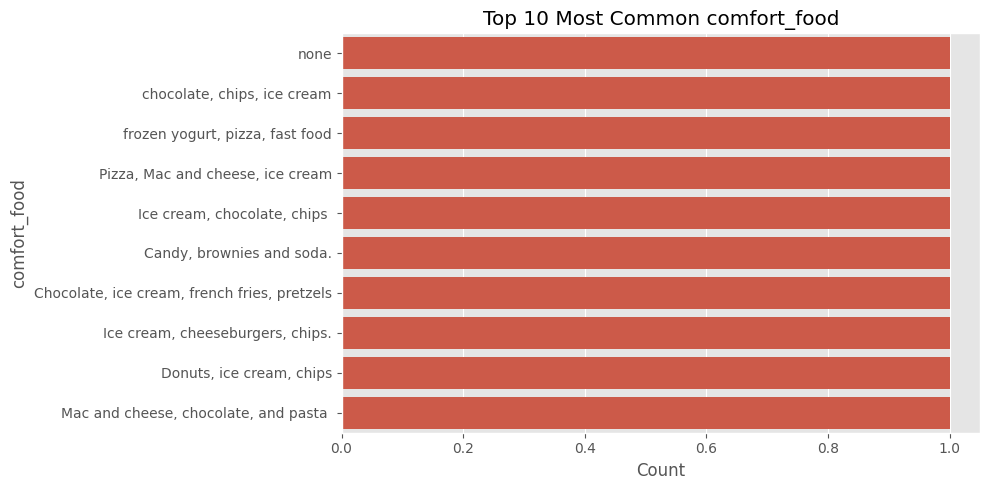

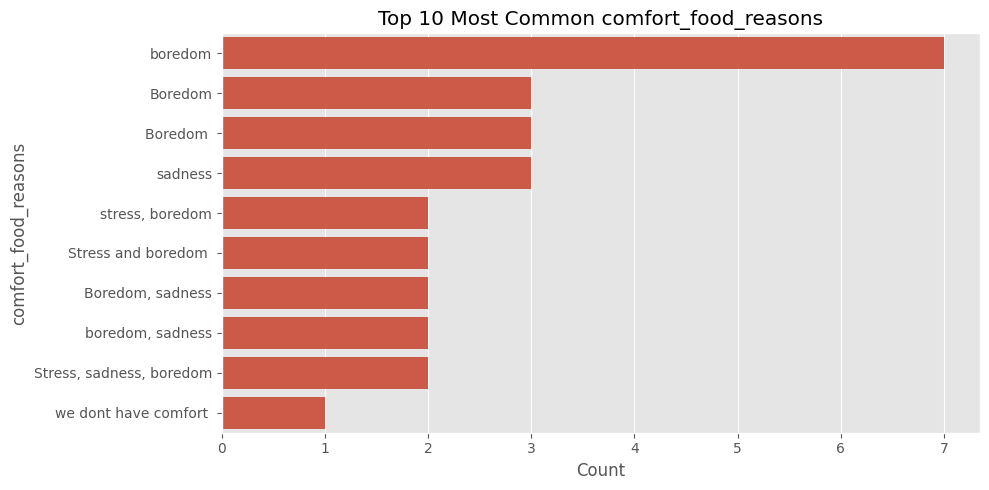

/tmp/ipykernel_590/3687185025.py:37: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


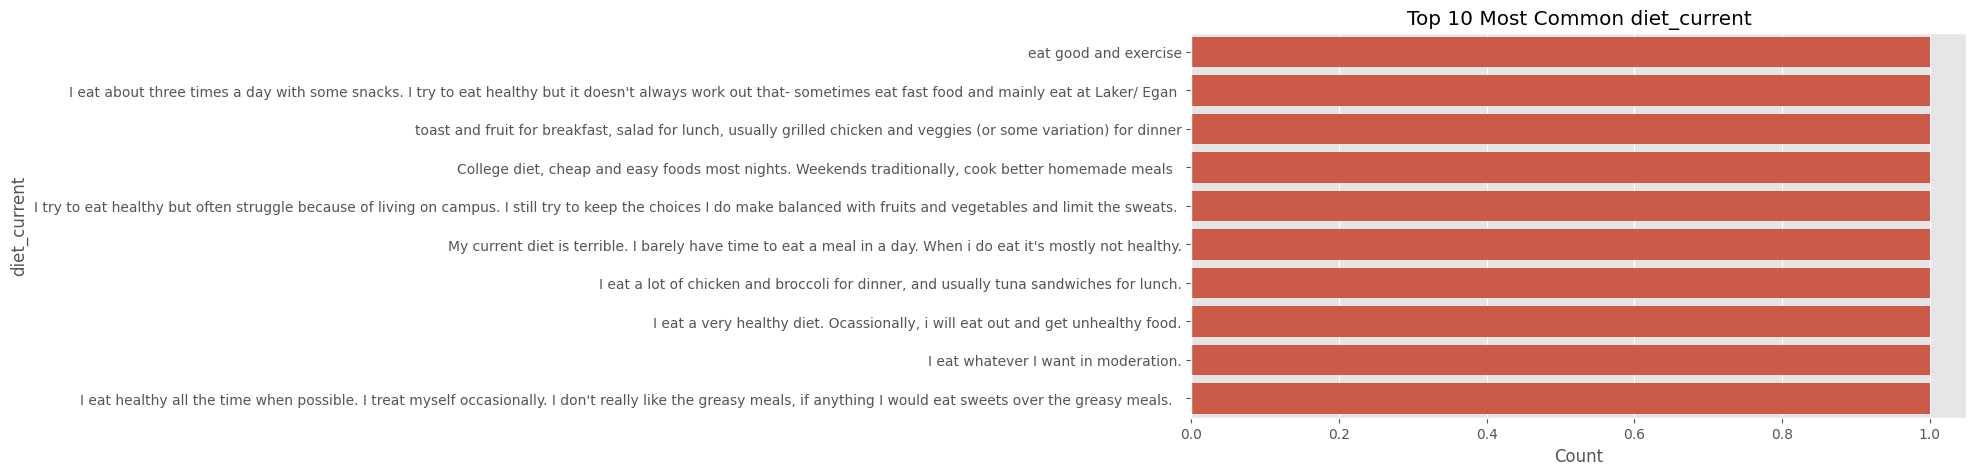

/tmp/ipykernel_590/3687185025.py:37: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


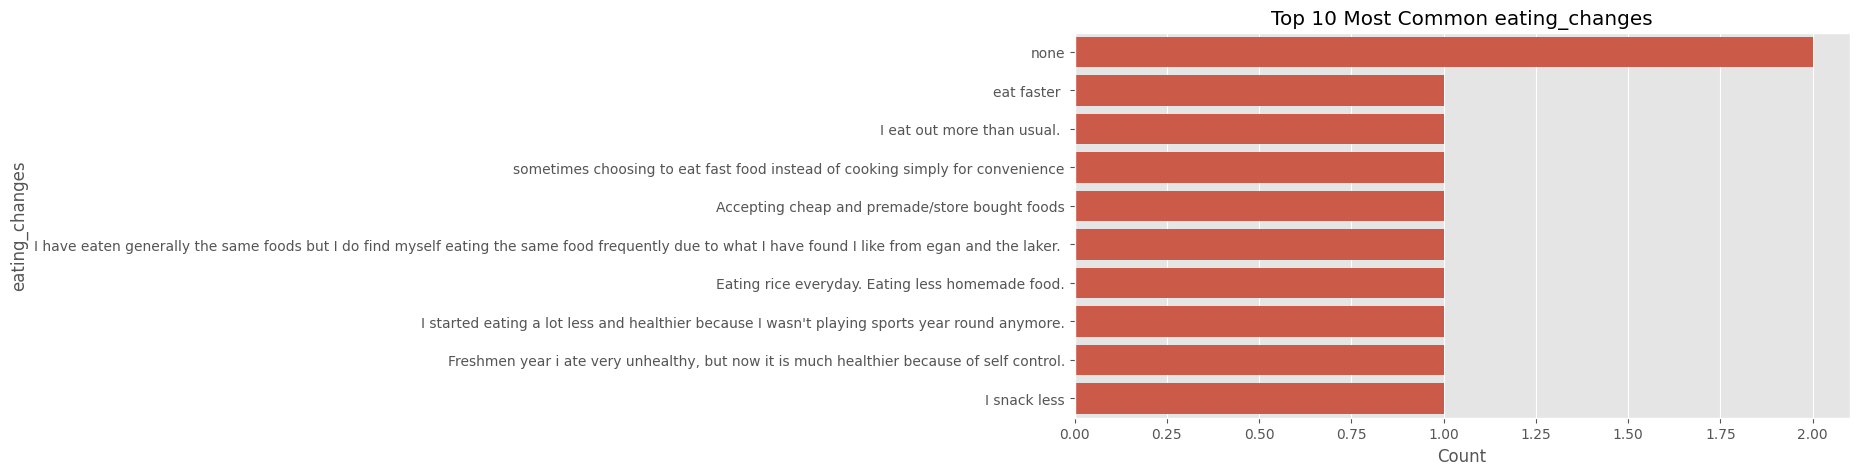

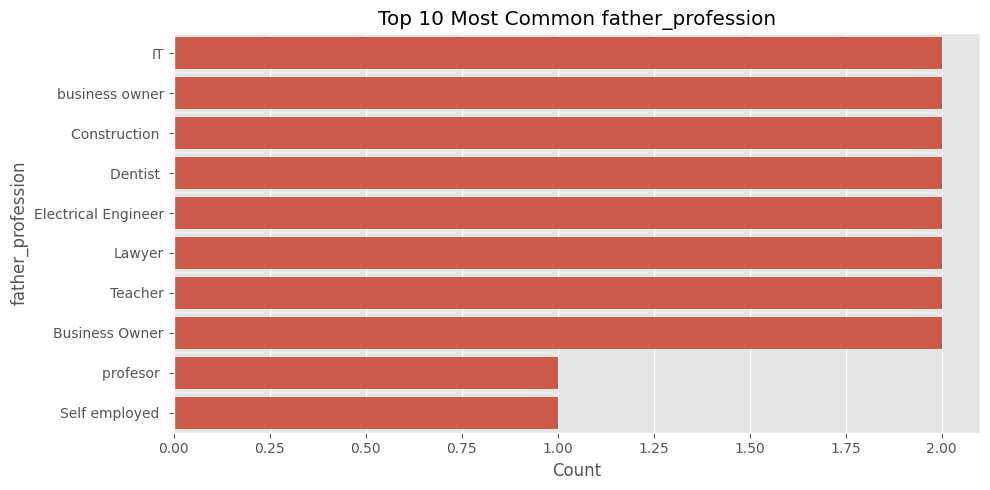

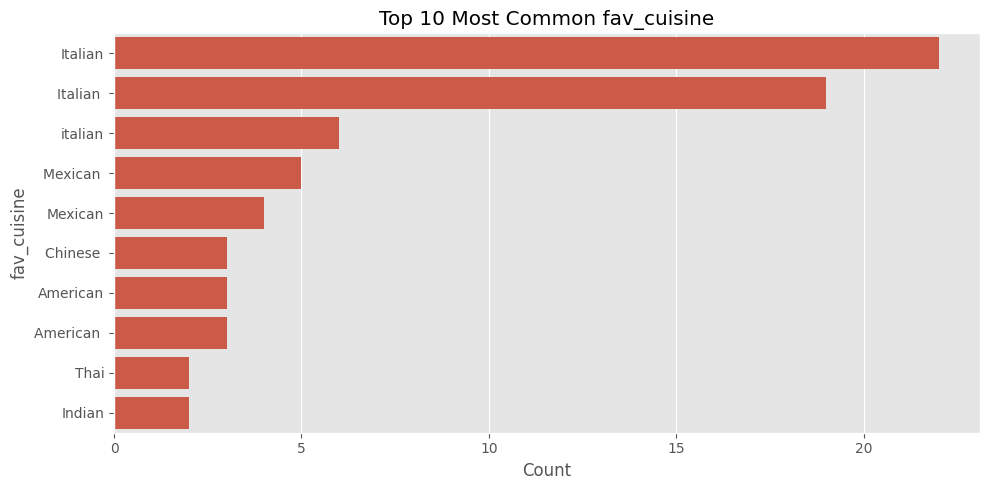

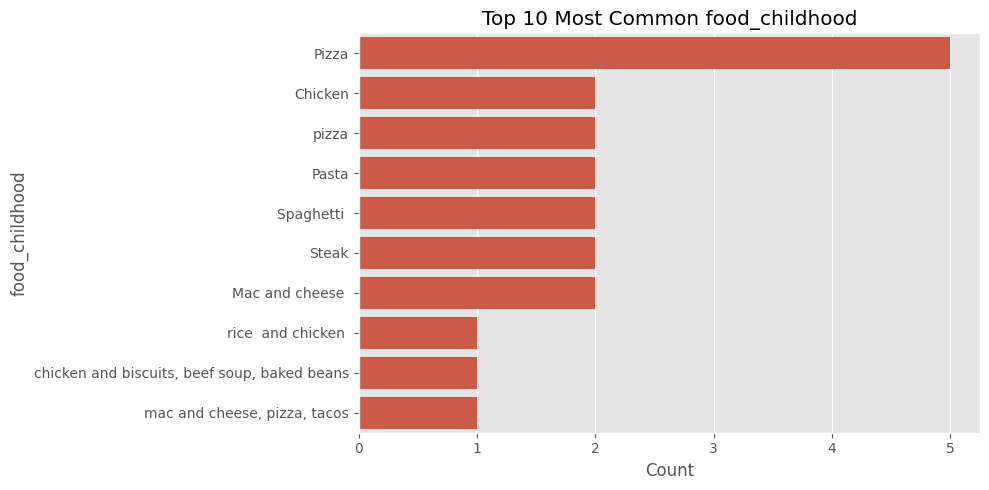

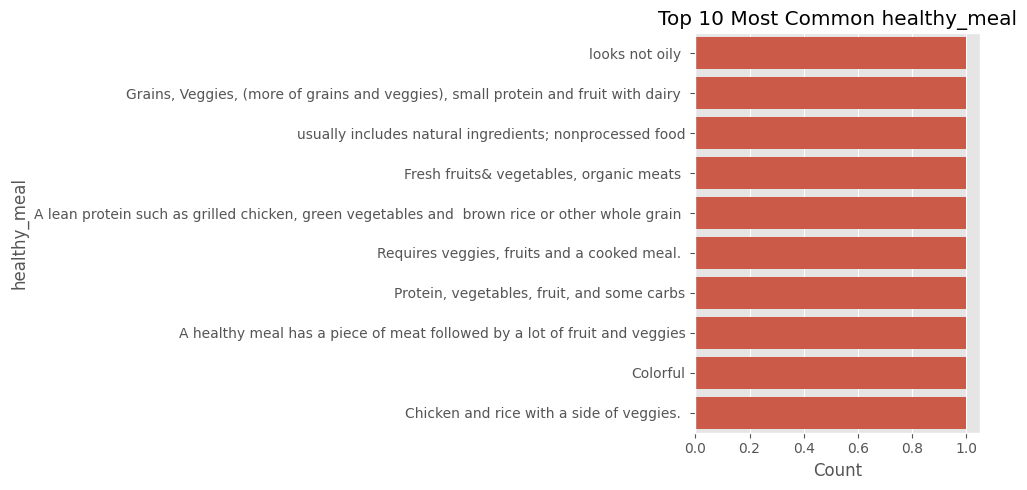

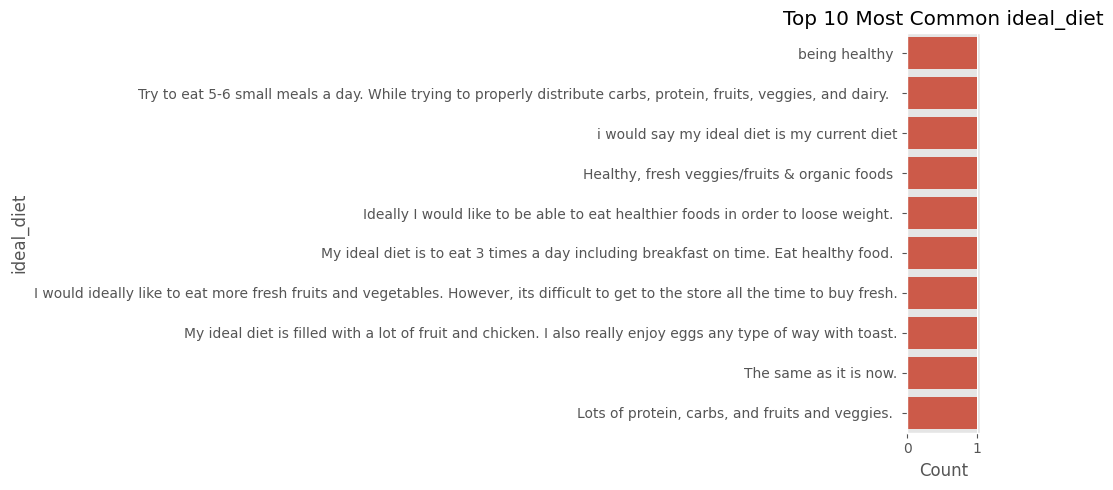

/tmp/ipykernel_590/3687185025.py:37: UserWarning: Glyph 13 (
) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 13 (
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


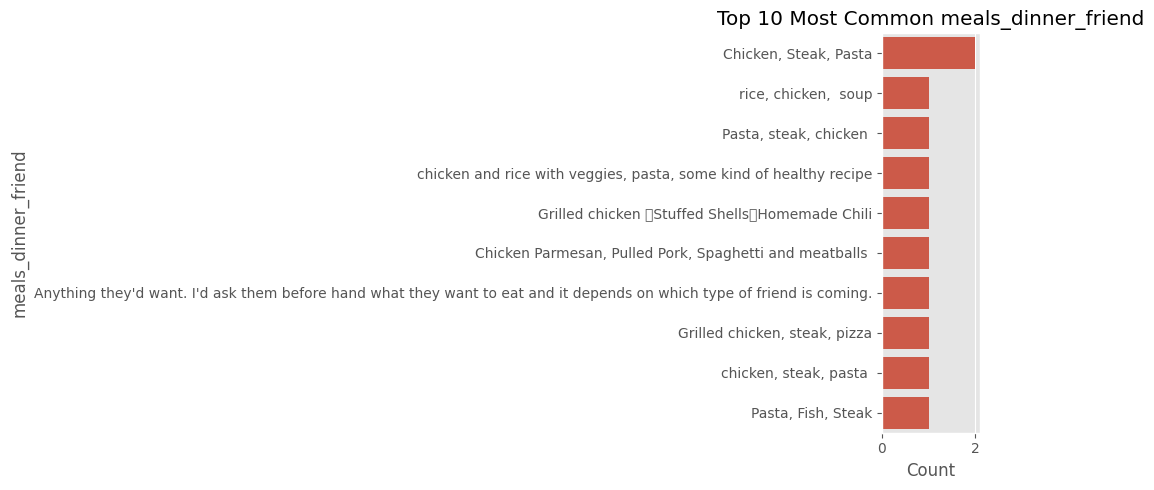

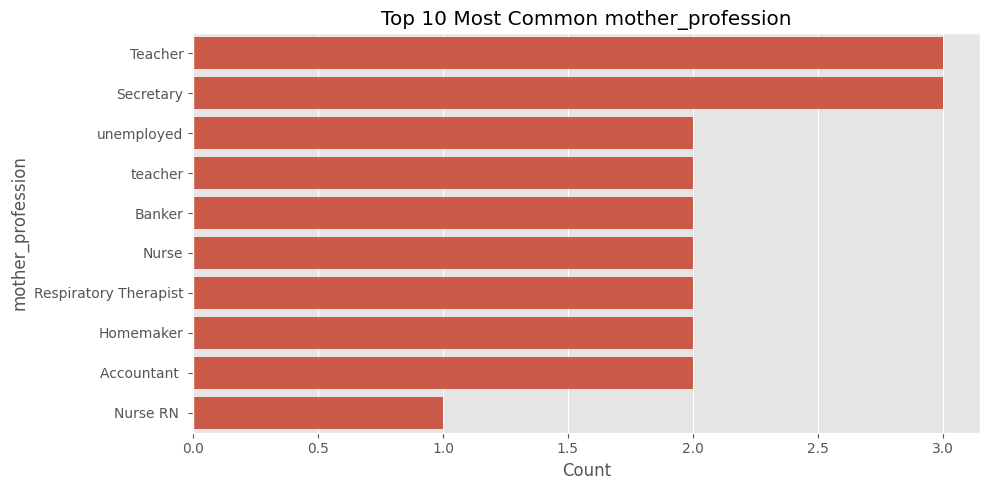

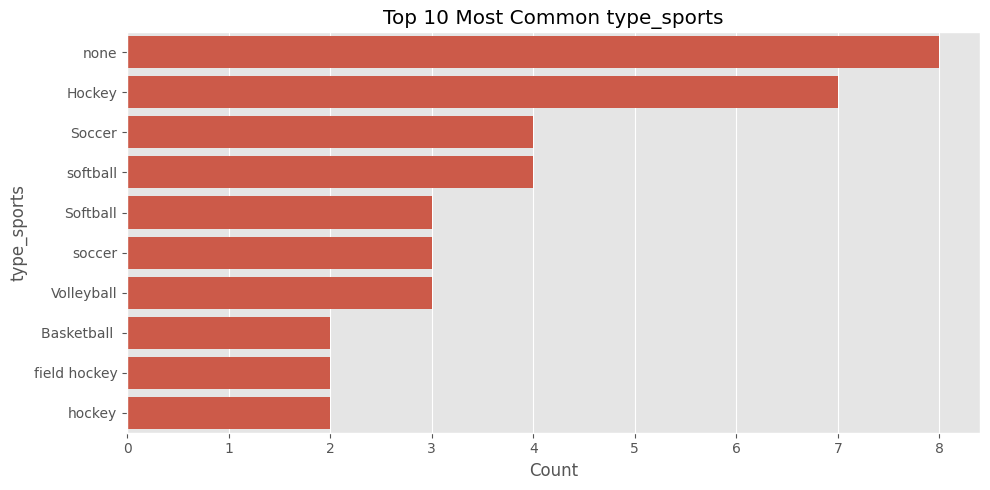

In [15]:
categorical_features = [
    "comfort_food",
    "comfort_food_reasons",
    "diet_current",
    "eating_changes",
    "father_profession",
    "fav_cuisine",
    "food_childhood",
    "healthy_meal",
    "ideal_diet",
    "meals_dinner_friend",
    "mother_profession",
    "type_sports",
]

top_n = 10

for col in categorical_features:
    if col not in df.columns:
        continue

    counts = df[col].value_counts().head(top_n)

    plt.figure(figsize=(10, 5))

    sns.barplot(x=counts.values, y=counts.index)

    plt.title(f"Top {top_n} Most Common {col}")

    plt.xlabel("Count")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

## Clean categorical data

In [16]:
def normalize_text(text):
    if pd.isna(text):
        return text

    text = str(text).lower()
    text = text.strip()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)

    return text


object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    df[col] = df[col].apply(normalize_text)

/tmp/ipykernel_590/1910099252.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include="object").columns


In [17]:
def clean_comfort_reason(text):
    if pd.isna(text):
        return text

    if "bored" in text:
        return "boredom"

    if "stress" in text:
        return "stress"

    if "sad" in text:
        return "sadness"

    if "happy" in text:
        return "happiness"

    if "depress" in text:
        return "depression"

    return text


df["comfort_food_reasons"] = df["comfort_food_reasons"].apply(clean_comfort_reason)

In [18]:
for col in object_cols:
    print(f"{col:30} {df[col].nunique()} unique values")

comfort_food                   124 unique values
comfort_food_reasons           18 unique values
diet_current                   124 unique values
eating_changes                 121 unique values
father_profession              101 unique values
fav_cuisine                    48 unique values
food_childhood                 108 unique values
healthy_meal                   123 unique values
ideal_diet                     124 unique values
meals_dinner_friend            115 unique values
mother_profession              104 unique values
type_sports                    47 unique values


In [19]:
for col in object_cols:
    print("=" * 60)
    print(col)

    print(df[col].value_counts().head(20))

comfort_food
comfort_food
none                                                       1
chocolate chips ice cream                                  1
frozen yogurt pizza fast food                              1
pizza mac and cheese ice cream                             1
ice cream chocolate chips                                  1
candy brownies and soda                                    1
chocolate ice cream french fries pretzels                  1
ice cream cheeseburgers chips                              1
donuts ice cream chips                                     1
mac and cheese chocolate and pasta                         1
pasta grandma homemade chocolate cake anything homemade    1
chocolate pasta soup chips popcorn                         1
cookies popcorn and chips                                  1
ice cream cake chocolate                                   1
pizza fruit spaghetti chicken and potatoes                 1
cookies donuts candy bars                                  

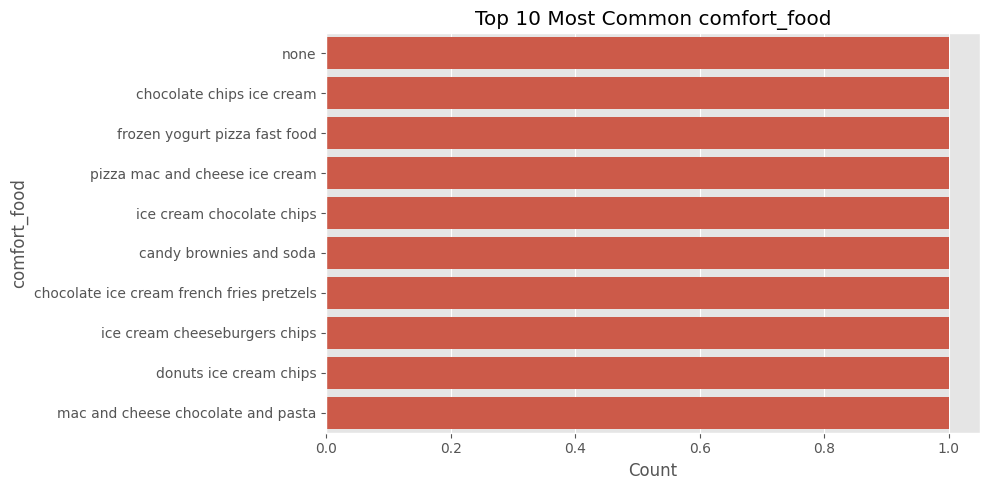

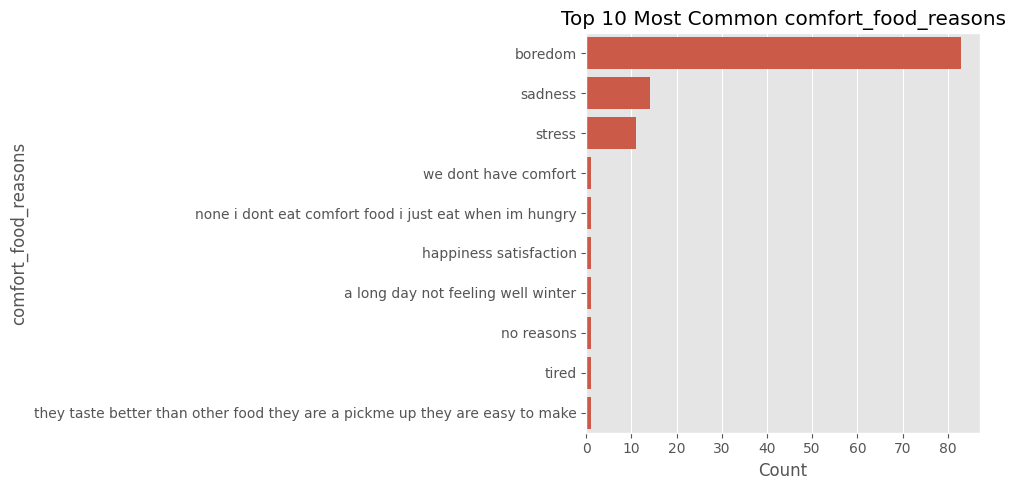

/tmp/ipykernel_590/2872941165.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


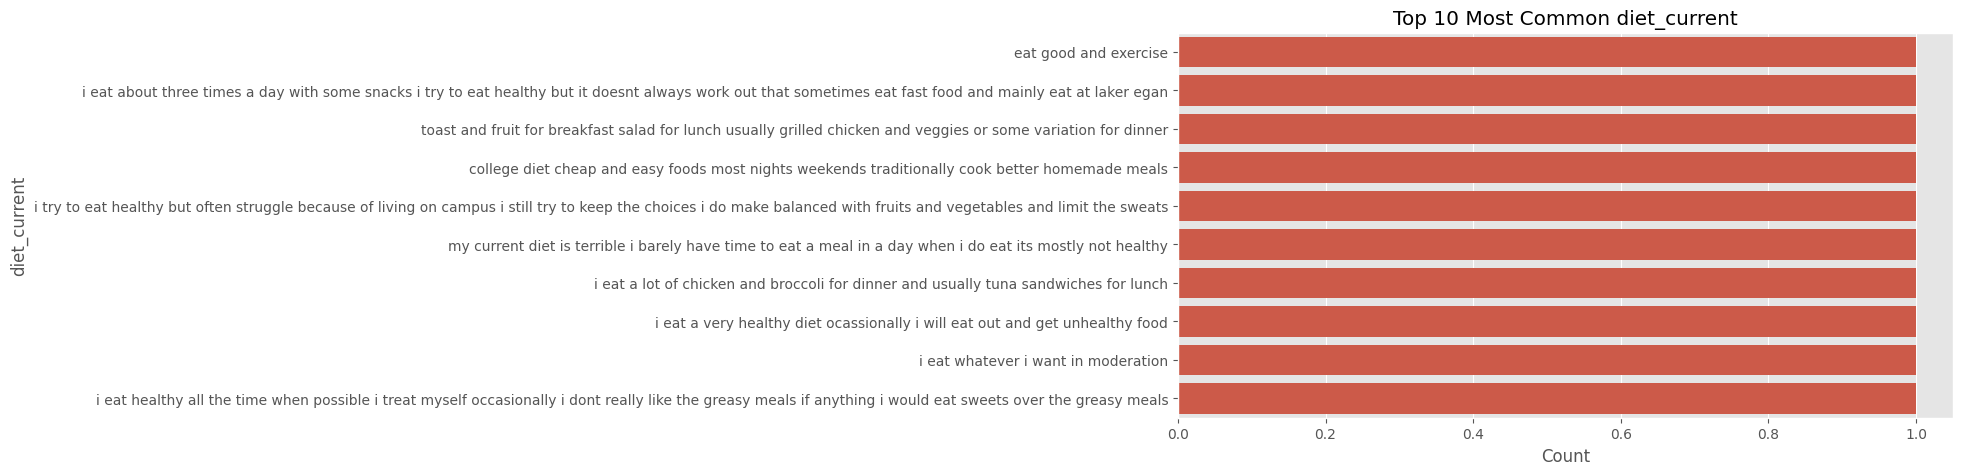

/tmp/ipykernel_590/2872941165.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


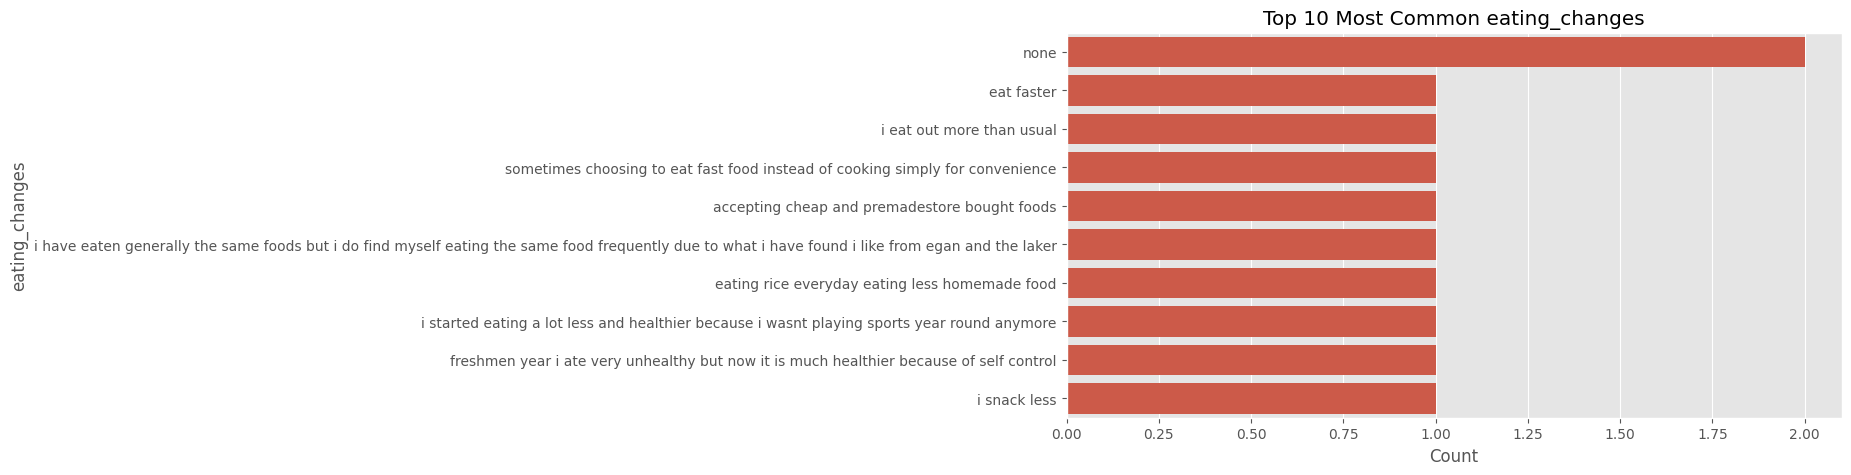

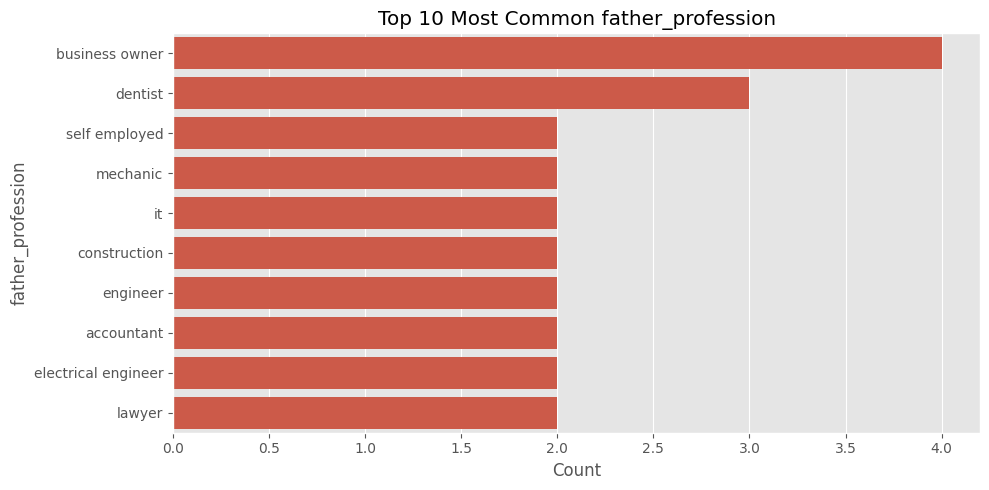

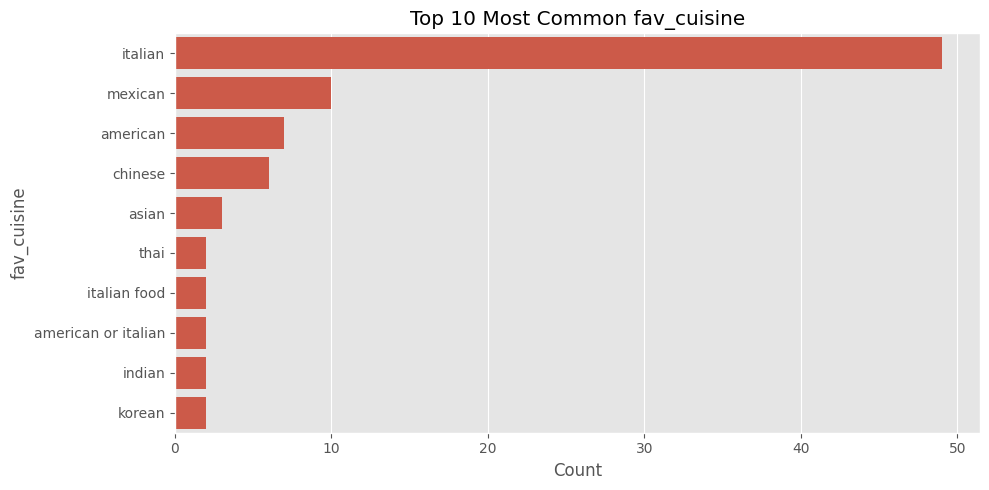

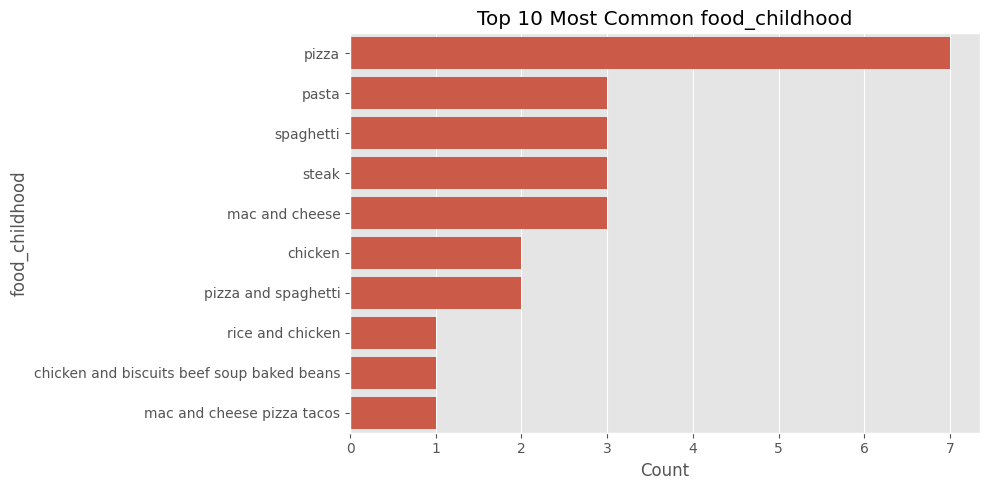

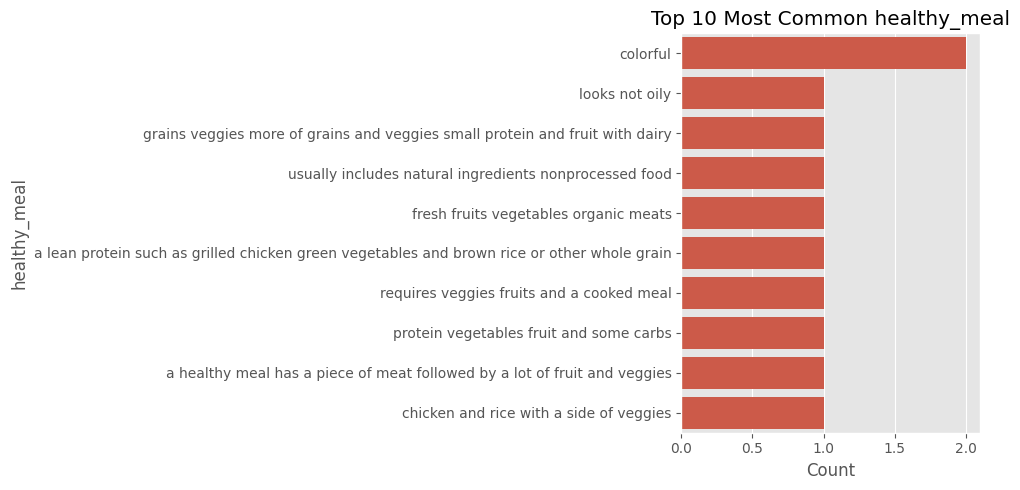

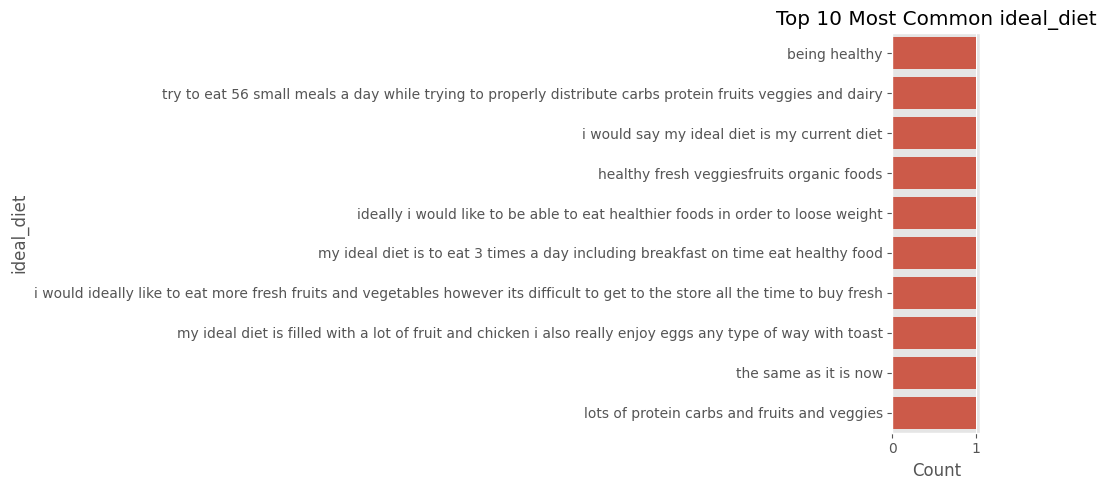

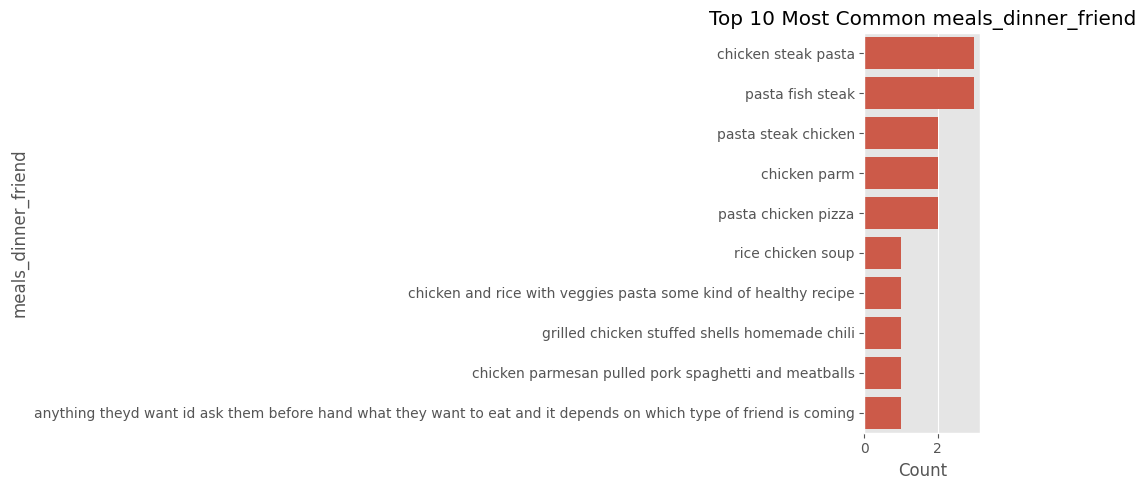

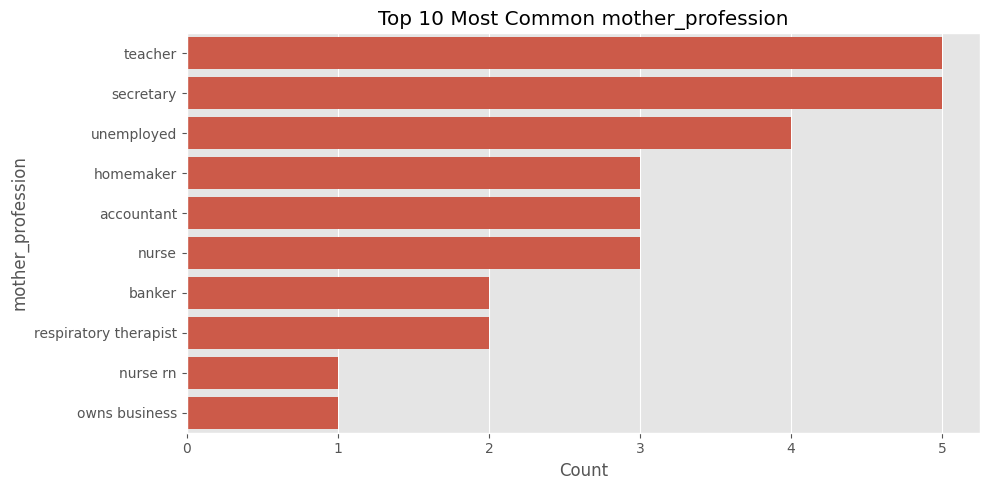

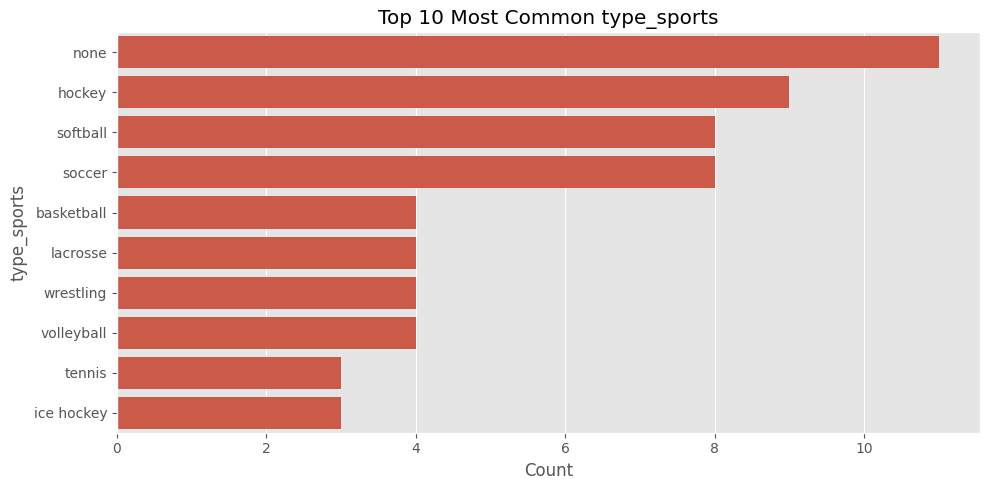

In [20]:
top_n_clean = 10

for col in object_cols:
    if col not in df.columns:
        continue

    counts = df[col].value_counts().head(top_n)

    plt.figure(figsize=(10, 5))

    sns.barplot(x=counts.values, y=counts.index)

    plt.title(f"Top {top_n} Most Common {col}")

    plt.xlabel("Count")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

## 9. Correlation with GPA

In [21]:
corr_gpa = df[numeric_cols].corr()["GPA"].sort_values(ascending=False)

corr_gpa

GPA                             1.000000
grade_level                     0.237820
turkey_calories                 0.231468
ethnic_food                     0.215631
parents_cook                    0.193205
thai_food                       0.187303
on_off_campus                   0.137721
indian_food                     0.135502
calories_chicken                0.134665
soup                            0.131949
nutritional_check               0.121042
italian_food                    0.116321
veggies_day                     0.107042
income                          0.072243
fruit_day                       0.041070
eating_changes_coded1           0.037695
greek_food                      0.035371
calories_day                    0.014489
tortilla_calories               0.013088
mother_education                0.009725
persian_food                    0.008885
waffle_calories                 0.007659
self_perception_weight          0.001401
pay_meal_out                   -0.011533
marital_status  

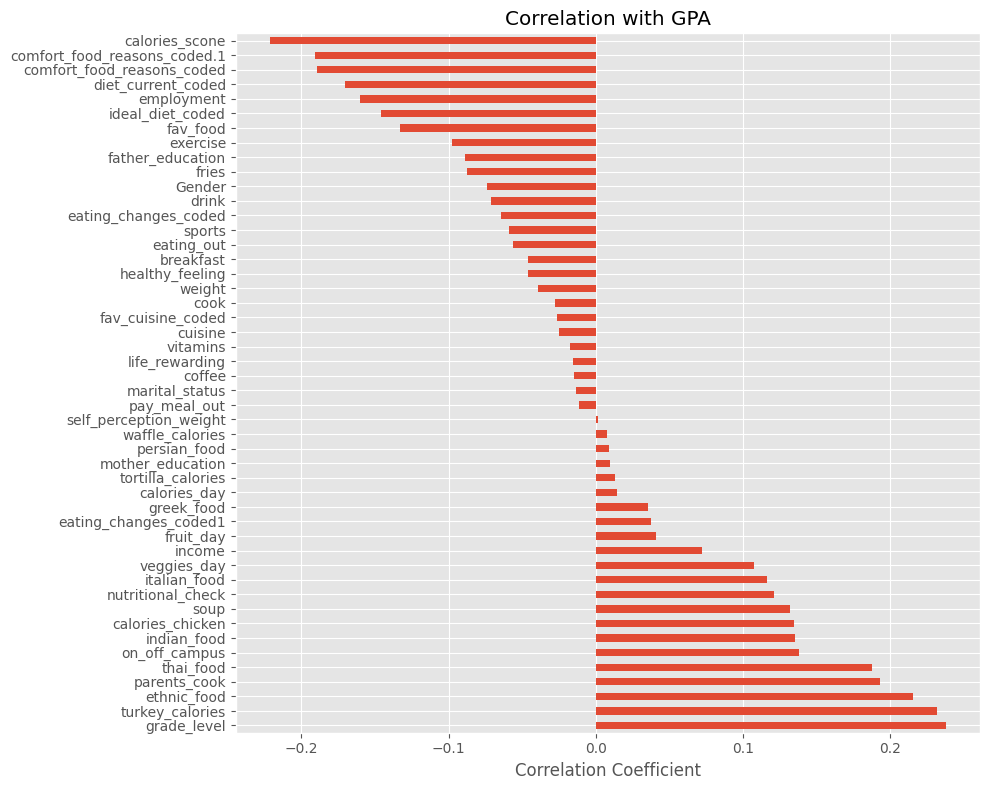

In [22]:
plt.figure(figsize=(10, 8))

corr_gpa.drop("GPA").plot(kind="barh")

plt.title("Correlation with GPA")
plt.xlabel("Correlation Coefficient")

plt.tight_layout()
plt.show()

## 10. GPA Outlier Detection (IQR Method)

In [23]:
Q1 = df["GPA"].quantile(0.25)
Q3 = df["GPA"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["GPA"] < lower) | (df["GPA"] > upper)]

print(f"Number of GPA Outliers: {len(outliers)}")

outliers[["GPA", "Gender", "exercise", "weight"]]

Number of GPA Outliers: 3


,GPA,Gender,exercise,weight
0,2.40,2,1.0,187.0
5,2.25,1,2.0,190.0
19,2.20,2,2.0,165.0


# Taco's

## Re-initiate Data Processing for SHAP and Model Training

As requested, we will re-initialize the DataFrame from the raw data and apply transformations only up to the 'Purge Unencodable Datas' stage. Then, we will proceed with SHAP analysis and model training to select features based on their importance as determined by SHAP.

In [24]:
# Reload the original dataset
df = pd.read_csv("data/food_coded.csv")

# Re-apply initial cleaning steps
df["GPA"] = pd.to_numeric(df["GPA"], errors="coerce")
df["weight"] = pd.to_numeric(df["weight"], errors="coerce")


# Re-apply text normalization for object columns
def normalize_text(text):
    if pd.isna(text):
        return text
    text = str(text).lower()
    text = text.strip()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text


object_cols = df.select_dtypes(include="object").columns
for col in object_cols:
    df[col] = df[col].apply(normalize_text)


# Re-apply comfort reason cleaning
def clean_comfort_reason(text):
    if pd.isna(text):
        return text
    if "bored" in text:
        return "boredom"
    if "stress" in text:
        return "stress"
    if "sad" in text:
        return "sadness"
    if "happy" in text:
        return "happiness"
    if "depress" in text:
        return "depression"
    return text


df["comfort_food_reasons"] = df["comfort_food_reasons"].apply(clean_comfort_reason)

# Re-apply Purge Unencodable Datas
cols_to_purge = []
for col in object_cols:
    if col in df.columns:
        string_values = df[col].dropna()
        if not string_values.empty and any(
            string_values.apply(
                lambda x: isinstance(x, str) and x.count(" ") >= 3 and len(x) >= 25
            )
        ):
            cols_to_purge.append(col)

df = df.drop(
    columns=cols_to_purge, errors="ignore"
)  # Use errors='ignore' in case some columns were already dropped

print("DataFrame shape after purging unencodable object columns:", df.shape)
print("Remaining object columns:", df.select_dtypes(include="object").columns.tolist())

DataFrame shape after purging unencodable object columns: (125, 49)
Remaining object columns: []


/tmp/ipykernel_590/135868702.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include="object").columns


## Re-run SHAP Analysis for Feature Selection

Now, with the DataFrame cleaned up to the 'Purge Unencodable Datas' stage, we will proceed with the SHAP analysis to identify important features. This will be followed by purging features not deemed important by SHAP, and then re-training the regression models.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
import shap

# Handle missing values in numerical columns using median imputation
numeric_features = df.select_dtypes(include=np.number).columns.drop(
    "GPA", errors="ignore"
)

imputer = SimpleImputer(strategy="median")
df[numeric_features] = imputer.fit_transform(df[numeric_features])

# Drop rows where 'GPA' is NaN, as it's our target variable
df.dropna(subset=["GPA"], inplace=True)

# Define features (X) and target (y)
X = df[numeric_features]
y = df["GPA"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Training Random Forest Regressor and Gradient Boosting Regressor

In [26]:
# Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)
print(f"Random Forest Regressor - MAE: {rf_mae:.3f}, R-squared: {rf_r2:.3f}")

# Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)
gb_mae = mean_absolute_error(y_test, gb_preds)
gb_r2 = r2_score(y_test, gb_preds)
print(f"Gradient Boosting Regressor - MAE: {gb_mae:.3f}, R-squared: {gb_r2:.3f}")

Random Forest Regressor - MAE: 0.324, R-squared: 0.114
Gradient Boosting Regressor - MAE: 0.362, R-squared: -0.118


### SHAP Results

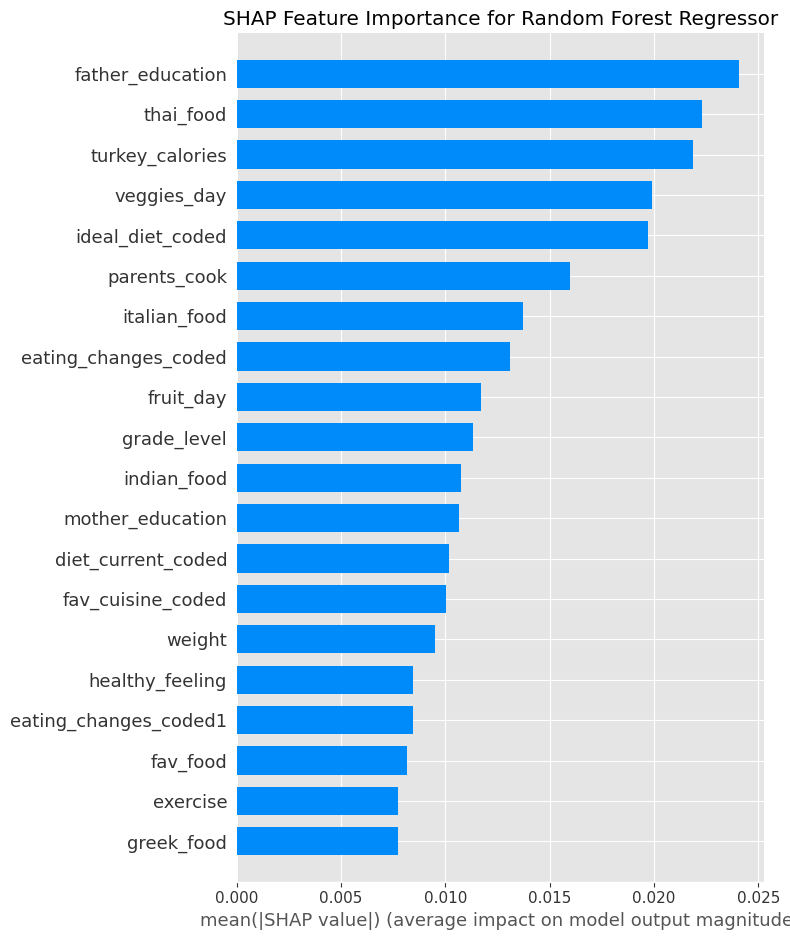

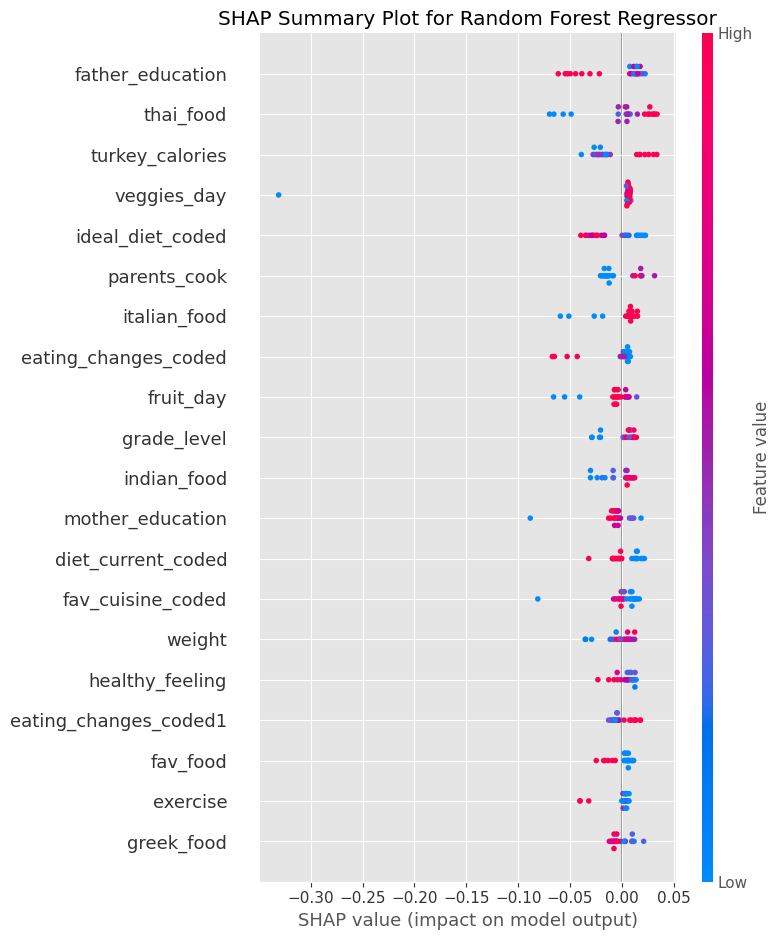

In [27]:
# Create a SHAP explainer for the Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Plot SHAP summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance for Random Forest Regressor")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot for Random Forest Regressor")
plt.tight_layout()
plt.show()

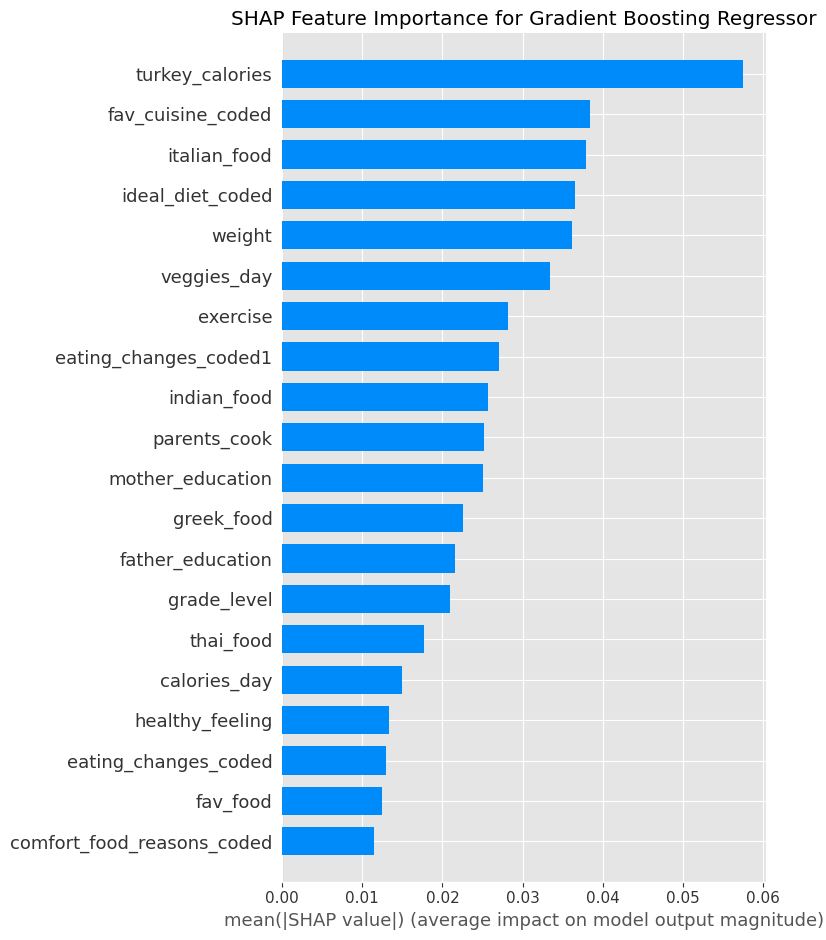

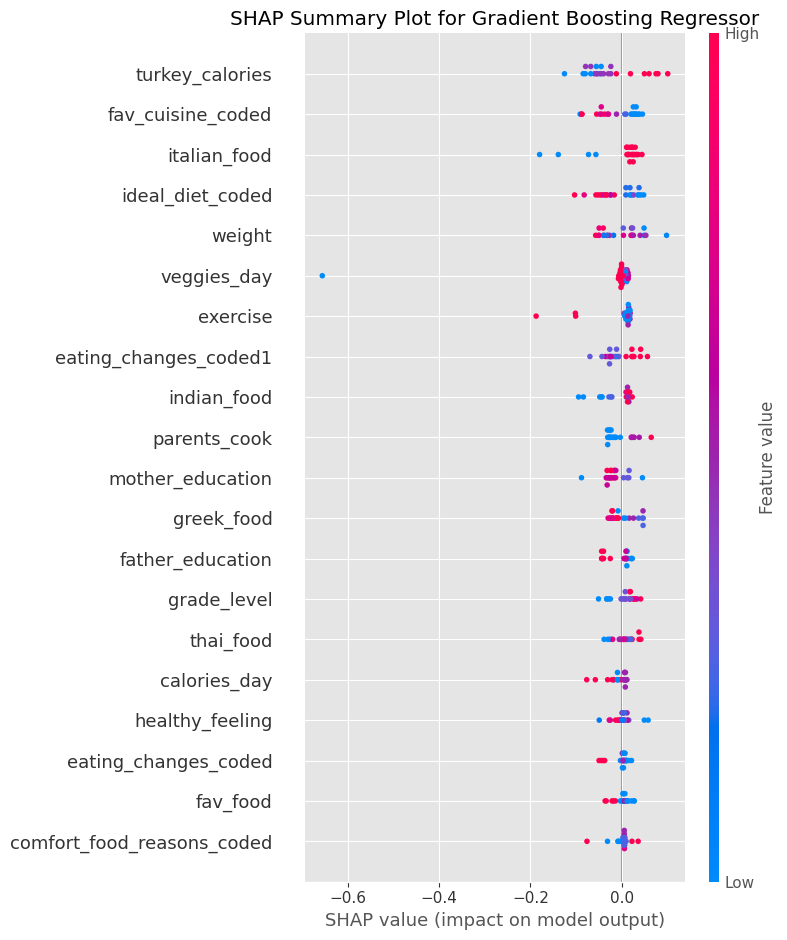

In [28]:
# 1. Initialize TreeExplainer for Gradient Boosting
gb_explainer = shap.TreeExplainer(gb_model)
gb_shap_values = gb_explainer.shap_values(X_test)

# 2. Generate standard beeswarm summary plot
shap.summary_plot(gb_shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance for Gradient Boosting Regressor")
plt.tight_layout()
plt.show()

shap.summary_plot(gb_shap_values, X_test, show=False)
plt.title("SHAP Summary Plot for Gradient Boosting Regressor")
plt.tight_layout()
plt.show()

In [29]:
# Get feature names
feature_names = X_test.columns

# Calculate mean absolute SHAP values for Random Forest
rf_shap_importance = pd.Series(
    np.abs(shap_values).mean(0), index=feature_names
).sort_values(ascending=False)

# Calculate mean absolute SHAP values for Gradient Boosting
gb_shap_importance = pd.Series(
    np.abs(gb_shap_values).mean(0), index=feature_names
).sort_values(ascending=False)

# Combine into a DataFrame for comparison
combined_shap_importance = pd.DataFrame(
    {
        "RandomForest_SHAP": rf_shap_importance,
        "GradientBoosting_SHAP": gb_shap_importance,
    }
).fillna(0)

print(
    "Combined SHAP Feature Importances (Mean Absolute SHAP Value, sorted by Random Forest):"
)
display(
    combined_shap_importance.sort_values(by="RandomForest_SHAP", ascending=False).head(
        15
    )
)

print(
    "\nCombined SHAP Feature Importances (Mean Absolute SHAP Value, sorted by Gradient Boosting):"
)
display(
    combined_shap_importance.sort_values(
        by="GradientBoosting_SHAP", ascending=False
    ).head(15)
)

# As an alternative, let's find features with mean absolute SHAP value > 0.01 in both models
threshold = 0.01
rf_important_features = set(rf_shap_importance[rf_shap_importance > threshold].index)
gb_important_features = set(gb_shap_importance[gb_shap_importance > threshold].index)

agreed_upon_important_features_by_threshold = list(
    rf_important_features.intersection(gb_important_features)
)

print(
    f"\nFeatures agreed upon as important (mean absolute SHAP > {threshold} for both):"
)
print(agreed_upon_important_features_by_threshold)

Combined SHAP Feature Importances (Mean Absolute SHAP Value, sorted by Random Forest):


,RandomForest_SHAP,GradientBoosting_SHAP
father_education,0.024064,0.021529
thai_food,0.022278,0.017761
turkey_calories,0.021858,0.057458
veggies_day,0.019888,0.033391
ideal_diet_coded,0.019698,0.036508
parents_cook,0.015963,0.025209
italian_food,0.013739,0.037960
eating_changes_coded,0.013104,0.012944
fruit_day,0.011690,0.006210
grade_level,0.011327,0.020997



Combined SHAP Feature Importances (Mean Absolute SHAP Value, sorted by Gradient Boosting):


,RandomForest_SHAP,GradientBoosting_SHAP
turkey_calories,0.021858,0.057458
fav_cuisine_coded,0.010023,0.038435
italian_food,0.013739,0.037960
ideal_diet_coded,0.019698,0.036508
weight,0.009520,0.036196
veggies_day,0.019888,0.033391
exercise,0.007718,0.028221
eating_changes_coded1,0.008444,0.027010
indian_food,0.010737,0.025699
parents_cook,0.015963,0.025209



Features agreed upon as important (mean absolute SHAP > 0.01 for both):
['father_education', 'indian_food', 'ideal_diet_coded', 'turkey_calories', 'italian_food', 'mother_education', 'fav_cuisine_coded', 'thai_food', 'parents_cook', 'eating_changes_coded', 'grade_level', 'veggies_day']


### SHAP Agreement Visualization

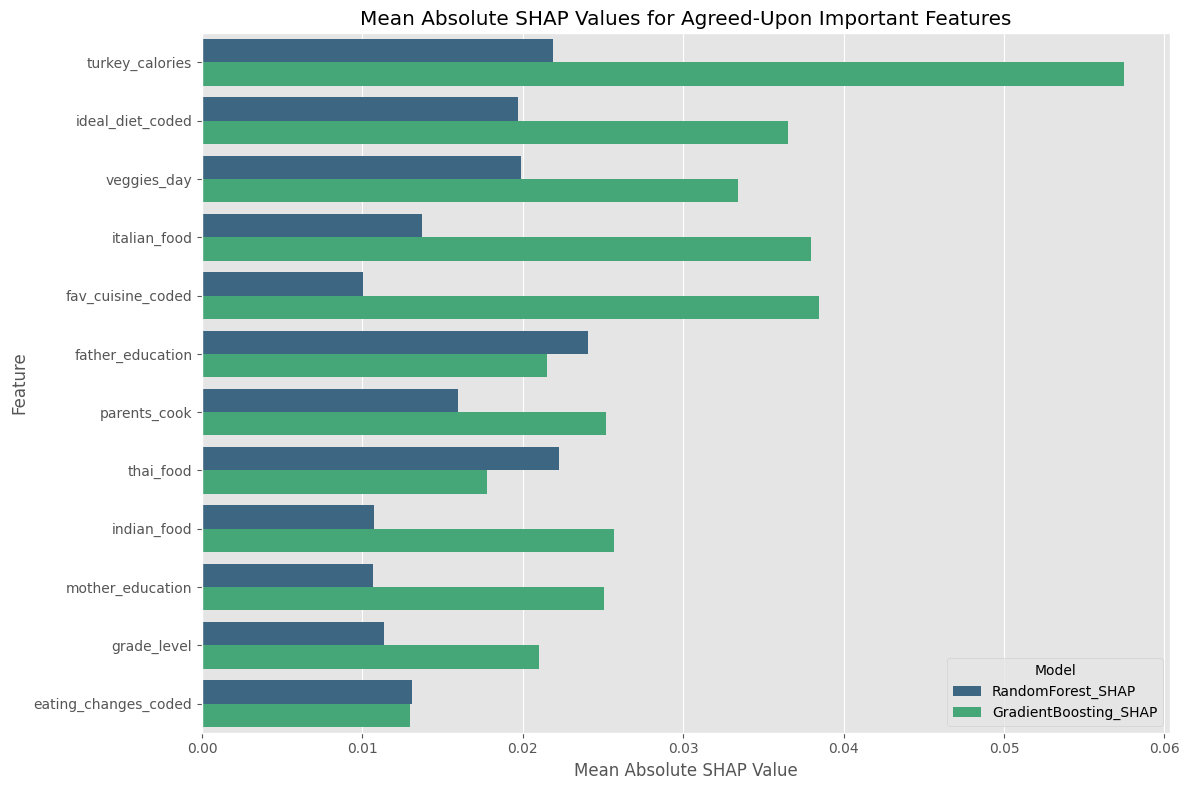

In [30]:
# Filter the combined SHAP importance to include only the agreed-upon features
agreed_features_df = combined_shap_importance.loc[
    agreed_upon_important_features_by_threshold
]

# Sort for better visualization (e.g., by the average SHAP value of both models)
agreed_features_df["Mean_SHAP"] = agreed_features_df.mean(axis=1)
agreed_features_df = agreed_features_df.sort_values(
    by="Mean_SHAP", ascending=False
).drop(columns=["Mean_SHAP"])

# Prepare data for plotting
plot_df = agreed_features_df.reset_index().melt(
    id_vars="index", var_name="Model", value_name="Mean Absolute SHAP Value"
)
plot_df.rename(columns={"index": "Feature"}, inplace=True)

plt.figure(figsize=(12, 8))
sns.barplot(
    x="Mean Absolute SHAP Value",
    y="Feature",
    hue="Model",
    data=plot_df,
    palette="viridis",
)
plt.title("Mean Absolute SHAP Values for Agreed-Upon Important Features")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

## SHAP Feature-Selection Stability (Bootstrap)

The `agreed_upon_important_features_by_threshold` list above comes from **one** train/test split. Given how weak the RF/GB fits are (R² of 0.11 and -0.12 on that split), there's a real risk that list is fitting split-specific noise rather than a stable signal.

To check that, we bootstrap the entire selection procedure: resample the rows with replacement, re-split, refit both RF and GB, recompute SHAP importance, and recompute which features clear the `> 0.01` bar for **both** models — repeated 100 times. A feature we can actually trust should show up in the agreed-set most of the time, not just once.

Selection frequency across 100 bootstrap resamples (share of runs a feature was 'agreed important'):
parents_cook                    0.71
weight                          0.66
father_education                0.65
grade_level                     0.63
fav_cuisine_coded               0.51
diet_current_coded              0.50
nutritional_check               0.49
eating_changes_coded1           0.49
ideal_diet_coded                0.47
turkey_calories                 0.46
calories_scone                  0.40
mother_education                0.39
healthy_feeling                 0.36
ethnic_food                     0.36
fruit_day                       0.32
italian_food                    0.31
thai_food                       0.29
comfort_food_reasons_coded.1    0.26
life_rewarding                  0.25
indian_food                     0.25
dtype: float64

Single-split agreed features (12): ['eating_changes_coded', 'father_education', 'fav_cuisine_coded', 'grade_level', 'ideal_diet_coded', 'indian

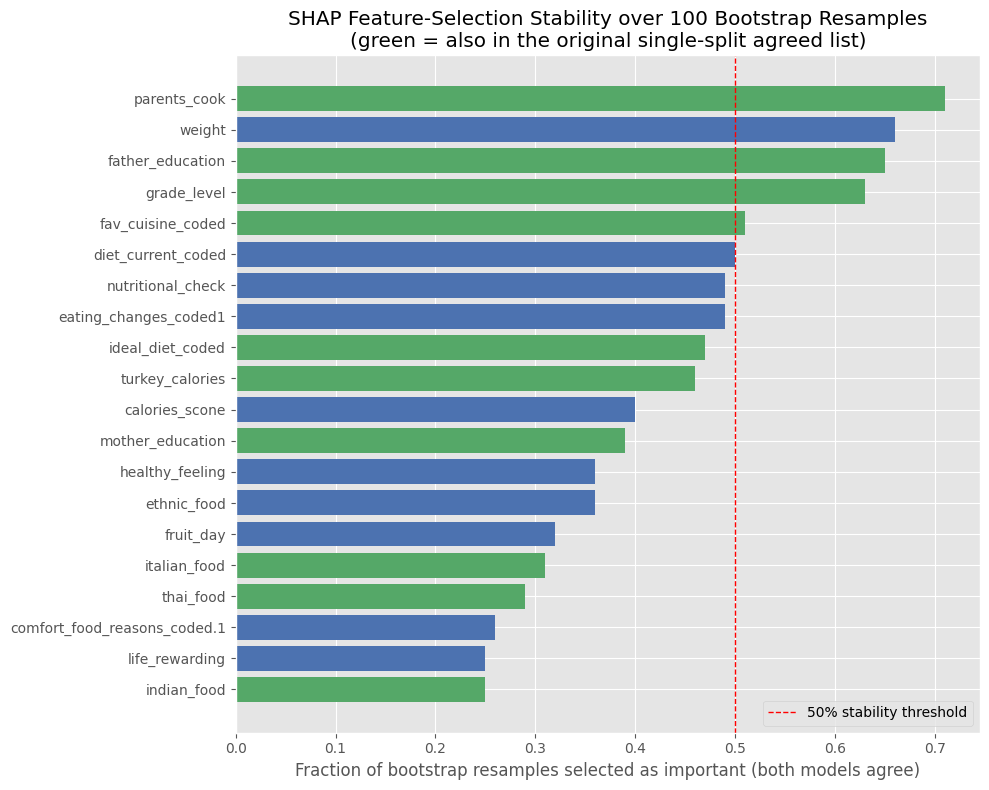

In [31]:
from sklearn.utils import resample

n_boot = 100
threshold = 0.01
rng = np.random.RandomState(42)

selection_counts = pd.Series(0, index=numeric_features)

for b in range(n_boot):
    Xb, yb = resample(X, y, random_state=rng.randint(0, 1_000_000))
    Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
        Xb, yb, test_size=0.2, random_state=rng.randint(0, 1_000_000)
    )

    rf_b = RandomForestRegressor(random_state=0).fit(Xb_tr, yb_tr)
    gb_b = GradientBoostingRegressor(random_state=0).fit(Xb_tr, yb_tr)

    rf_imp_b = np.abs(shap.TreeExplainer(rf_b).shap_values(Xb_te)).mean(0)
    gb_imp_b = np.abs(shap.TreeExplainer(gb_b).shap_values(Xb_te)).mean(0)

    rf_sel_b = set(Xb_te.columns[rf_imp_b > threshold])
    gb_sel_b = set(Xb_te.columns[gb_imp_b > threshold])

    selection_counts[list(rf_sel_b & gb_sel_b)] += 1

selection_freq = (selection_counts / n_boot).sort_values(ascending=False)

print(
    f"Selection frequency across {n_boot} bootstrap resamples (share of runs a feature was 'agreed important'):"
)
print(selection_freq.head(20))

# Compare against the single-split result from the cell above
single_split_agreed = set(agreed_upon_important_features_by_threshold)
stable_agreed = set(selection_freq[selection_freq >= 0.5].index)

print(
    f"\nSingle-split agreed features ({len(single_split_agreed)}): {sorted(single_split_agreed)}"
)
print(
    f"Bootstrap-stable features, freq>=0.5 ({len(stable_agreed)}): {sorted(stable_agreed)}"
)
print(f"Overlap: {sorted(single_split_agreed & stable_agreed)}")

plt.figure(figsize=(10, 8))
top_freq = selection_freq.head(20)
colors = ["#55A868" if f in single_split_agreed else "#4C72B0" for f in top_freq.index]
plt.barh(top_freq.index[::-1], top_freq.values[::-1], color=colors[::-1])
plt.axvline(
    0.5, color="red", linestyle="--", linewidth=1, label="50% stability threshold"
)
plt.xlabel("Fraction of bootstrap resamples selected as important (both models agree)")
plt.title(
    f"SHAP Feature-Selection Stability over {n_boot} Bootstrap Resamples\n(green = also in the original single-split agreed list)"
)
plt.legend()
plt.tight_layout()
plt.show()

## Purge Disagreed Features (based on SHAP)

In [32]:
# Identify all current features in the DataFrame (excluding 'GPA')
current_features = df.columns.drop("GPA", errors="ignore").tolist()

# Identify features that are in the current DataFrame but NOT in the agreed_upon_important_features_by_threshold
disagreed_features_to_purge = [
    feat
    for feat in current_features
    if feat not in agreed_upon_important_features_by_threshold
]

print(
    f"Features to be purged (not agreed upon as important): {disagreed_features_to_purge}"
)

# Drop these disagreed features from the DataFrame
df = df.drop(columns=disagreed_features_to_purge)

print("\nDataFrame shape after purging disagreed features:")
print(df.shape)

# Update numeric_cols to reflect the new set of features
numeric_cols = df.select_dtypes(include=np.number).columns
print("\nUpdated numeric columns:")
print(numeric_cols.tolist())

Features to be purged (not agreed upon as important): ['Gender', 'breakfast', 'calories_chicken', 'calories_day', 'calories_scone', 'coffee', 'comfort_food_reasons_coded', 'cook', 'comfort_food_reasons_coded.1', 'cuisine', 'diet_current_coded', 'drink', 'eating_changes_coded1', 'eating_out', 'employment', 'ethnic_food', 'exercise', 'fav_food', 'fries', 'fruit_day', 'greek_food', 'healthy_feeling', 'income', 'life_rewarding', 'marital_status', 'nutritional_check', 'on_off_campus', 'pay_meal_out', 'persian_food', 'self_perception_weight', 'soup', 'sports', 'tortilla_calories', 'vitamins', 'waffle_calories', 'weight']

DataFrame shape after purging disagreed features:
(120, 13)

Updated numeric columns:
['GPA', 'eating_changes_coded', 'father_education', 'fav_cuisine_coded', 'grade_level', 'ideal_diet_coded', 'indian_food', 'italian_food', 'mother_education', 'parents_cook', 'thai_food', 'turkey_calories', 'veggies_day']


In [33]:
df.info()

<class 'pandas.DataFrame'>
Index: 120 entries, 0 to 124
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   GPA                   120 non-null    float64
 1   eating_changes_coded  120 non-null    float64
 2   father_education      120 non-null    float64
 3   fav_cuisine_coded     120 non-null    float64
 4   grade_level           120 non-null    float64
 5   ideal_diet_coded      120 non-null    float64
 6   indian_food           120 non-null    float64
 7   italian_food          120 non-null    float64
 8   mother_education      120 non-null    float64
 9   parents_cook          120 non-null    float64
 10  thai_food             120 non-null    float64
 11  turkey_calories       120 non-null    float64
 12  veggies_day           120 non-null    float64
dtypes: float64(13)
memory usage: 13.1 KB


## Re-train Regression Models and Residual Analysis (with SHAP-selected features)

--- Model Training and Evaluation ---

Training Linear Regression...
Linear Regression - MAE: 0.326, R-squared: 0.183

Training Random Forest Regressor...
Random Forest Regressor - MAE: 0.364, R-squared: -0.160

Training Gradient Boosting Regressor...
Gradient Boosting Regressor - MAE: 0.342, R-squared: 0.003

Training XGBoost Regressor...
XGBoost Regressor - MAE: 0.411, R-squared: -0.319

--- Residual Analysis ---


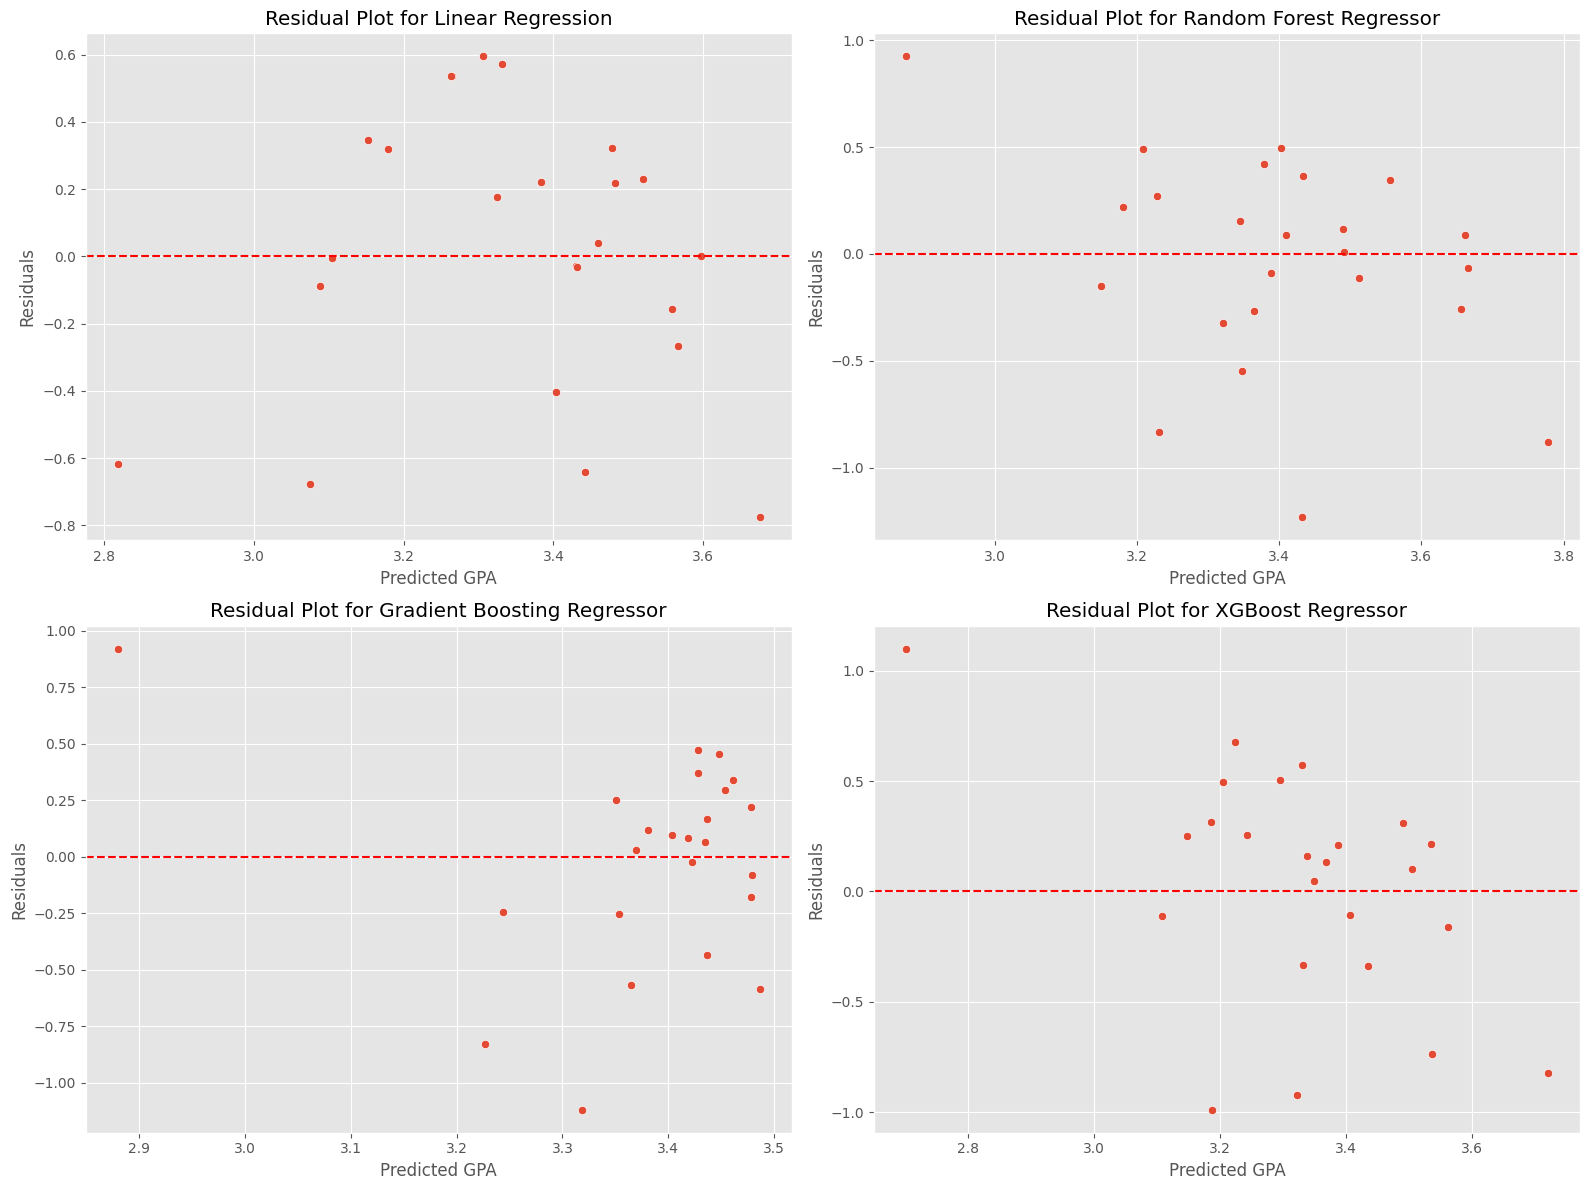

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Redefine features (X) and target (y) from the latest df state
X_new = df.drop(columns=["GPA"])
y_new = df["GPA"]

# Split data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

# Initialize and train the models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=10, random_state=42
    ),  # 10 'epochs'
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=10, random_state=42
    ),  # 10 'epochs'
    "XGBoost Regressor": XGBRegressor(n_estimators=10, random_state=42),  # 10 'epochs'
}

predictions = {}
metrics = {}

print("--- Model Training and Evaluation ---\n")
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_new, y_train_new)
    preds = model.predict(X_test_new)
    predictions[name] = preds

    mae = mean_absolute_error(y_test_new, preds)
    r2 = r2_score(y_test_new, preds)
    metrics[name] = {"MAE": mae, "R-squared": r2}

    print(f"{name} - MAE: {mae:.3f}, R-squared: {r2:.3f}\n")

print("--- Residual Analysis ---")
plt.figure(figsize=(16, 12))

for i, (name, preds) in enumerate(predictions.items()):
    residuals = y_test_new - preds

    plt.subplot(2, 2, i + 1)  # Create a 2x2 grid of plots
    sns.scatterplot(x=preds, y=residuals)
    plt.axhline(y=0, color="r", linestyle="--")
    plt.title(f"Residual Plot for {name}")
    plt.xlabel("Predicted GPA")
    plt.ylabel("Residuals")
    plt.grid(True)

plt.tight_layout()
plt.show()

## Cross-Validated Model Comparison

The single 80/20 split above is noisy on a dataset this small (120 rows). Repeating the comparison with 5-fold cross-validation gives a more reliable picture of which model generalizes best before we commit to one for testing.

In [35]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for name, model in models.items():
    mae_scores = -cross_val_score(
        model, X_new, y_new, cv=cv, scoring="neg_mean_absolute_error"
    )
    r2_scores = cross_val_score(model, X_new, y_new, cv=cv, scoring="r2")
    cv_rows.append(
        {
            "model": name,
            "MAE_mean": mae_scores.mean(),
            "MAE_std": mae_scores.std(),
            "R2_mean": r2_scores.mean(),
            "R2_std": r2_scores.std(),
        }
    )

cv_comparison_df = pd.DataFrame(cv_rows).sort_values("MAE_mean").reset_index(drop=True)
print("5-fold CV comparison (lower MAE / higher R-squared is better):")
display(cv_comparison_df)

best_name = cv_comparison_df.iloc[0]["model"]
best_model = models[best_name]
best_model.fit(X_new, y_new)
print(f"\nBest model by CV MAE: {best_name}")

5-fold CV comparison (lower MAE / higher R-squared is better):


,model,MAE_mean,MAE_std,R2_mean,R2_std
0,Linear Regression,0.302422,0.013754,-0.051199,0.229929
1,Gradient Boosting Regressor,0.305212,0.024341,-0.021775,0.140751
2,Random Forest Regressor,0.330686,0.018926,-0.266604,0.518776
3,XGBoost Regressor,0.336572,0.041124,-0.319892,0.423929



Best model by CV MAE: Linear Regression


## SHAP Waterfall — Explaining Individual Predictions

Aggregate SHAP bar/summary plots show which features matter *on average*. A waterfall plot instead explains **one specific prediction**: starting from the model's average output (`E[f(X)]`), it shows how each feature value pushes that one prediction up or down to arrive at the final predicted GPA. We look at the best-predicted and worst-predicted rows in the held-out test set from the SHAP-selected-feature model (`best_model`).

Best-predicted row  -> index 72: actual=3.100, predicted=3.087
Worst-predicted row -> index 41: actual=2.900, predicted=3.630


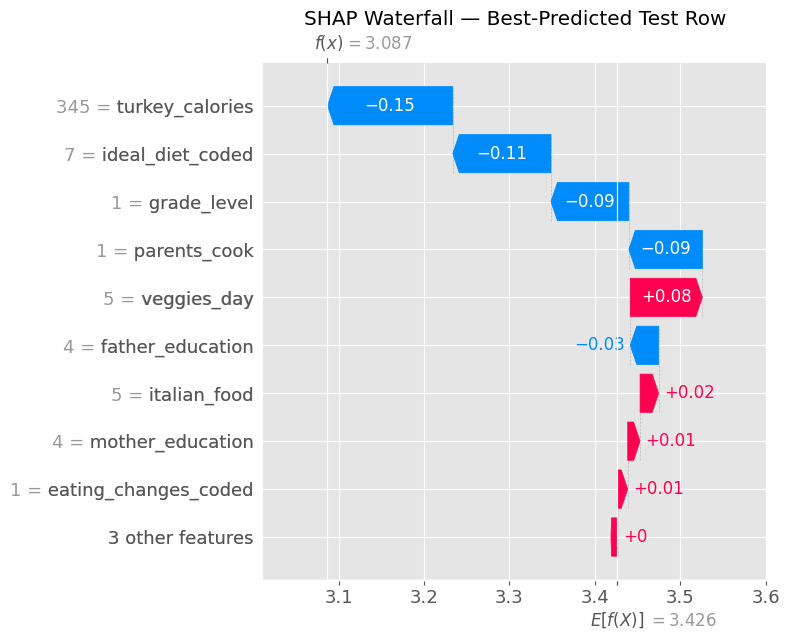

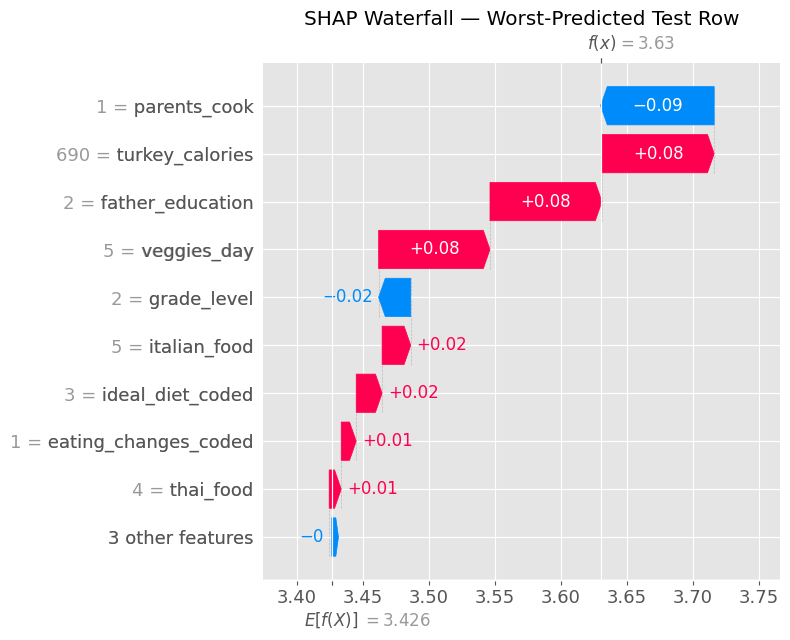

In [36]:
wf_explainer = shap.Explainer(best_model, X_train_new)
wf_shap_values = wf_explainer(X_test_new)

wf_preds = best_model.predict(X_test_new)
wf_errors = y_test_new.values - wf_preds

best_pos = int(np.argmin(np.abs(wf_errors)))  # smallest error
worst_pos = int(np.argmax(np.abs(wf_errors)))  # largest error

print(
    f"Best-predicted row  -> index {X_test_new.index[best_pos]}: actual={y_test_new.values[best_pos]:.3f}, "
    f"predicted={wf_preds[best_pos]:.3f}"
)
print(
    f"Worst-predicted row -> index {X_test_new.index[worst_pos]}: actual={y_test_new.values[worst_pos]:.3f}, "
    f"predicted={wf_preds[worst_pos]:.3f}"
)

plt.figure()
shap.plots.waterfall(wf_shap_values[best_pos], show=False)
plt.title("SHAP Waterfall — Best-Predicted Test Row")
plt.tight_layout()
plt.show()

plt.figure()
shap.plots.waterfall(wf_shap_values[worst_pos], show=False)
plt.title("SHAP Waterfall — Worst-Predicted Test Row")
plt.tight_layout()
plt.show()

## Anomaly Detection

The residual method above only flags anomalies relative to a single model's predictions on the test split. Here we add two multivariate, unsupervised methods that look at the feature space directly, independent of any regression target:

- **Isolation Forest** — isolates points that split away from the rest of the data in few random partitions.
- **Local Outlier Factor (LOF)** — flags points whose local density is much lower than their neighbors', catching outliers that Isolation Forest's axis-aligned splits can miss.

We compare both against each other and against the residual-based flags.

[Residual method] anomalies (test split, |resid| > 2*std): []
[Isolation Forest] anomalies: [0, 5, 16, 21, 25, 74, 77, 91, 111, 114, 115, 122]
[LOF] anomalies: [13, 20, 21, 22, 26, 29, 62, 79, 88, 90, 114, 119]

Agreed by both multivariate methods (IF ∩ LOF): [21, 114]


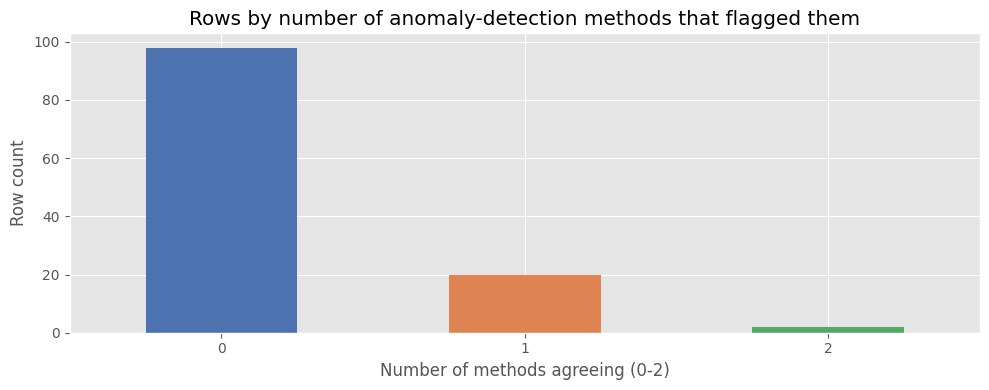

In [37]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Residual-based (Taco's original approach), reusing the best CV model refit on a held-out split
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)
resid_model = type(best_model)(**best_model.get_params())
resid_model.fit(X_train_new, y_train_new)
resid_preds = resid_model.predict(X_test_new)
residuals_final = y_test_new - resid_preds
resid_thresh = residuals_final.std() * 2
residual_anomaly_idx = residuals_final[
    residuals_final.abs() > resid_thresh
].index.tolist()
print(
    "[Residual method] anomalies (test split, |resid| > 2*std):", residual_anomaly_idx
)

# Isolation Forest - trained on the full selected-feature set
iso = IsolationForest(contamination=0.1, random_state=42)
iso_pred = iso.fit_predict(X_new)
iso_anomaly_idx = X_new.index[iso_pred == -1].tolist()
print("[Isolation Forest] anomalies:", iso_anomaly_idx)

# Local Outlier Factor - trained on the full selected-feature set
lof = LocalOutlierFactor(n_neighbors=15, contamination=0.1)
lof_pred = lof.fit_predict(X_new)
lof_anomaly_idx = X_new.index[lof_pred == -1].tolist()
print("[LOF] anomalies:", lof_anomaly_idx)

agreed_anomalies = sorted(set(iso_anomaly_idx) & set(lof_anomaly_idx))
print("\nAgreed by both multivariate methods (IF ∩ LOF):", agreed_anomalies)

# Visualize agreement
anomaly_summary = pd.DataFrame(
    {
        "row": X_new.index,
        "isolation_forest": X_new.index.isin(iso_anomaly_idx),
        "lof": X_new.index.isin(lof_anomaly_idx),
    }
).set_index("row")
anomaly_summary["flagged_by"] = anomaly_summary[["isolation_forest", "lof"]].sum(axis=1)

plt.figure(figsize=(10, 4))
anomaly_summary["flagged_by"].value_counts().sort_index().plot(
    kind="bar", color=["#4C72B0", "#DD8452", "#55A868"]
)
plt.title("Rows by number of anomaly-detection methods that flagged them")
plt.xlabel("Number of methods agreeing (0-2)")
plt.ylabel("Row count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
## Mask from SHAP feature selection

# example_mask = {result from purging}
# This is exactly the column set that survived the SHAP-agreement purge above (X_new.columns),
# kept in that same order so it lines up with how every downstream model was trained/fit.
example_mask = X_new.columns.tolist()
print("Feature mask (%d features):" % len(example_mask))
print(example_mask)


def masking(df, mask: list):
    return df[mask]

Feature mask (12 features):
['eating_changes_coded', 'father_education', 'fav_cuisine_coded', 'grade_level', 'ideal_diet_coded', 'indian_food', 'italian_food', 'mother_education', 'parents_cook', 'thai_food', 'turkey_calories', 'veggies_day']


## Taco has done (poorly)

- Feature engineering, yet it is poor quality (Try meditation)
- I didn't do the filter/wrapper yet (which you should do)
  - there is a dummy mask for it, look above

# What's |3anxna should do next

- perform anomalies dectection
  - I have tried with residule, but maybe we need other kind of anomalies detection

- train the model
  - Do some comparison (Small epoch because we need abstract class that I don't finish yet (likely to need to retrain locally IDK))

- Some testing


- ขอก่อนพรุ่งนี้ เราต้อง port เป็น .py ตอนเช้า ส่งคาบเริ่ม (checkpoint2)

---

## |3anxna's update

Done, in the order above:

- **Anomaly detection**: added Isolation Forest and Local Outlier Factor as multivariate
  complements to the residual method. They look at the feature space directly instead of
  model error, so they catch a different kind of outlier. Only the rows both methods agree
  on are worth treating as likely anomalies; single-method flags are too noisy at n=120.
- **Model training + comparison**: added 5-fold CV on top of the single-split comparison,
  since one split is not trustworthy at this sample size. Best model by CV MAE is selected
  and refit on all the SHAP-selected features.
- **Testing**: the mask is now the real SHAP-agreed feature list (not a stub), and the smoke
  test below runs an actual row through `masking()` and `model.predict()`.

Caveat worth flagging before this goes further: R-squared on this data hovers near zero
(sometimes negative) across every model we tried. With 120 rows and a self-reported survey
target, that's not a bug — GPA here is genuinely hard to predict from these features. Worth
deciding as a team whether the checkpoint framing should be "best model we could find" or
"here's why this is a hard prediction problem," since those lead to different next steps.


In [39]:
## Smoke test

# test_input = a fresh row with the full original feature set
test_input = X.iloc[[0]]
test_input = masking(test_input, example_mask)
result = best_model.predict(test_input)

print("Predicted GPA:", result[0])
print("Actual GPA:   ", y.iloc[0])

assert test_input.shape[1] == len(example_mask), (
    "masking did not select the expected columns"
)
assert result.shape == (1,), "unexpected prediction shape"
print("\nSmoke test passed: mask -> predict pipeline runs end-to-end.")

Predicted GPA: 2.951983522075706
Actual GPA:    2.4

Smoke test passed: mask -> predict pipeline runs end-to-end.
